In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

In [3]:
df = pd.read_excel(r'C:\Users\USER\OneDrive\Desktop\My Briefcase\Full stack analyst\World Prisons\Recidivism\resources\nij-challenge2021_full_dataset.xlsx')

In [4]:
df.head()

,ID,Gender,Race,Age_at_Release,Residence_PUMA,Gang_Affiliated,Supervision_Risk_Score_First,Supervision_Level_First,Education_Level,Dependents,...,DrugTests_Meth_Positive,DrugTests_Other_Positive,Percent_Days_Employed,Jobs_Per_Year,Employment_Exempt,Recidivism_Within_3years,Recidivism_Arrest_Year1,Recidivism_Arrest_Year2,Recidivism_Arrest_Year3,Training_Sample
0,1,M,BLACK,43-47,16,No,3.0,Standard,At least some college,3 or more,...,0.000000,0.0,0.488562,0.447610,No,No,No,No,No,1
1,2,M,BLACK,33-37,16,No,6.0,Specialized,Less than HS diploma,1,...,0.000000,0.0,0.425234,2.000000,No,Yes,No,No,Yes,1
2,3,M,BLACK,48 or older,24,No,7.0,High,At least some college,3 or more,...,0.166667,0.0,0.000000,0.000000,No,Yes,No,Yes,No,1
3,4,M,WHITE,38-42,16,No,7.0,High,Less than HS diploma,1,...,0.000000,0.0,1.000000,0.718996,No,No,No,No,No,1
4,5,M,WHITE,33-37,16,No,4.0,Specialized,Less than HS diploma,3 or more,...,0.058824,0.0,0.203562,0.929389,No,Yes,Yes,No,No,1


In [5]:
df.shape

(25835, 54)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25835 entries, 0 to 25834
Data columns (total 54 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   ID                                25835 non-null  int64  
 1   Gender                            25835 non-null  object 
 2   Race                              25835 non-null  object 
 3   Age_at_Release                    25835 non-null  object 
 4   Residence_PUMA                    25835 non-null  int64  
 5   Gang_Affiliated                   22668 non-null  object 
 6   Supervision_Risk_Score_First      25360 non-null  float64
 7   Supervision_Level_First           24115 non-null  object 
 8   Education_Level                   25835 non-null  object 
 9   Dependents                        25835 non-null  object 
 10  Prison_Offense                    22558 non-null  object 
 11  Prison_Years                      25835 non-null  object 
 12  Prio

In [7]:
df.isnull().sum().sort_values(ascending=False)

Avg_Days_per_DrugTest               6103
DrugTests_Meth_Positive             5172
DrugTests_THC_Positive              5172
DrugTests_Cocaine_Positive          5172
DrugTests_Other_Positive            5172
Prison_Offense                      3277
Gang_Affiliated                     3167
Supervision_Level_First             1720
Jobs_Per_Year                        808
Supervision_Risk_Score_First         475
Percent_Days_Employed                462
Violations_MoveWithoutPermission       0
Violations_FailToReport                0
Program_Attendances                    0
Violations_Instruction                 0
Violations_ElectronicMonitoring        0
Condition_Other                        0
Condition_Cog_Ed                       0
Delinquency_Reports                    0
ID                                     0
Program_UnexcusedAbsences              0
Residence_Changes                      0
Prior_Revocations_Probation            0
Employment_Exempt                      0
Recidivism_Withi

In [8]:
df['Recidivism_Within_3years'].value_counts(normalize=True)

Recidivism_Within_3years
Yes    0.576892
No     0.423108
Name: proportion, dtype: float64

In [9]:
df.describe(include='all')

,ID,Gender,Race,Age_at_Release,Residence_PUMA,Gang_Affiliated,Supervision_Risk_Score_First,Supervision_Level_First,Education_Level,Dependents,...,DrugTests_Meth_Positive,DrugTests_Other_Positive,Percent_Days_Employed,Jobs_Per_Year,Employment_Exempt,Recidivism_Within_3years,Recidivism_Arrest_Year1,Recidivism_Arrest_Year2,Recidivism_Arrest_Year3,Training_Sample
count,25835.000000,25835,25835,25835,25835.000000,22668,25360.000000,24115,25835,25835.0,...,20663.000000,20663.00000,25373.000000,25027.000000,25835,25835,25835,25835,25835,25835.000000
unique,NaN,2,2,7,NaN,2,NaN,3,3,4.0,...,NaN,NaN,NaN,NaN,2,2,2,2,2,NaN
top,NaN,M,BLACK,23-27,NaN,No,NaN,Standard,High School Diploma,0.0,...,NaN,NaN,NaN,NaN,No,Yes,No,No,No,NaN
freq,NaN,22668,14847,5176,NaN,18730,NaN,9983,11390,8037.0,...,NaN,NaN,NaN,NaN,22399,14904,18111,21268,23222,NaN
mean,13314.004838,NaN,NaN,NaN,12.361796,NaN,6.082216,NaN,NaN,NaN,...,0.012890,0.00755,0.482331,0.769295,NaN,NaN,NaN,NaN,NaN,0.697813
std,7722.206327,NaN,NaN,NaN,7.133742,NaN,2.381442,NaN,NaN,NaN,...,0.060581,0.04115,0.425004,0.813787,NaN,NaN,NaN,NaN,NaN,0.459215
min,1.000000,NaN,NaN,NaN,1.000000,NaN,1.000000,NaN,NaN,NaN,...,0.000000,0.00000,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,0.000000
25%,6626.500000,NaN,NaN,NaN,6.000000,NaN,4.000000,NaN,NaN,NaN,...,0.000000,0.00000,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,0.000000
50%,13270.000000,NaN,NaN,NaN,12.000000,NaN,6.000000,NaN,NaN,NaN,...,0.000000,0.00000,0.475728,0.635217,NaN,NaN,NaN,NaN,NaN,1.000000
75%,20021.500000,NaN,NaN,NaN,18.000000,NaN,8.000000,NaN,NaN,NaN,...,0.000000,0.00000,0.969325,1.000000,NaN,NaN,NaN,NaN,NaN,1.000000


In [10]:
df.nunique().sort_values(ascending=False)

ID                                  25835
Percent_Days_Employed               10997
Avg_Days_per_DrugTest                9833
Jobs_Per_Year                        3615
DrugTests_THC_Positive                377
DrugTests_Cocaine_Positive            249
DrugTests_Meth_Positive               244
DrugTests_Other_Positive              235
Residence_PUMA                         25
Prior_Arrest_Episodes_Felony           11
Program_Attendances                    11
Supervision_Risk_Score_First           10
Age_at_Release                          7
Prior_Arrest_Episodes_Misd              7
Prior_Arrest_Episodes_Property          6
Prior_Arrest_Episodes_Drug              6
_v1                                     6
Prior_Conviction_Episodes_Misd          5
Delinquency_Reports                     5
Prison_Offense                          5
Residence_Changes                       4
Program_UnexcusedAbsences               4
Prior_Conviction_Episodes_Prop          4
Prior_Arrest_Episodes_Violent     

In [11]:
# mISSING PERCENT
missing_percent = df.isnull().mean().sort_values(ascending=False) * 100
missing_percent.head(15)

Avg_Days_per_DrugTest               23.622992
DrugTests_Meth_Positive             20.019354
DrugTests_THC_Positive              20.019354
DrugTests_Cocaine_Positive          20.019354
DrugTests_Other_Positive            20.019354
Prison_Offense                      12.684343
Gang_Affiliated                     12.258564
Supervision_Level_First              6.657635
Jobs_Per_Year                        3.127540
Supervision_Risk_Score_First         1.838591
Percent_Days_Employed                1.788272
Violations_MoveWithoutPermission     0.000000
Violations_FailToReport              0.000000
Program_Attendances                  0.000000
Violations_Instruction               0.000000
dtype: float64

In [12]:
df.columns

Index(['ID', 'Gender', 'Race', 'Age_at_Release', 'Residence_PUMA',
       'Gang_Affiliated', 'Supervision_Risk_Score_First',
       'Supervision_Level_First', 'Education_Level', 'Dependents',
       'Prison_Offense', 'Prison_Years', 'Prior_Arrest_Episodes_Felony',
       'Prior_Arrest_Episodes_Misd', 'Prior_Arrest_Episodes_Violent',
       'Prior_Arrest_Episodes_Property', 'Prior_Arrest_Episodes_Drug', '_v1',
       'Prior_Arrest_Episodes_DVCharges', 'Prior_Arrest_Episodes_GunCharges',
       'Prior_Conviction_Episodes_Felony', 'Prior_Conviction_Episodes_Misd',
       'Prior_Conviction_Episodes_Viol', 'Prior_Conviction_Episodes_Prop',
       'Prior_Conviction_Episodes_Drug', '_v2', '_v3', '_v4',
       'Prior_Revocations_Parole', 'Prior_Revocations_Probation',
       'Condition_MH_SA', 'Condition_Cog_Ed', 'Condition_Other',
       'Violations_ElectronicMonitoring', 'Violations_Instruction',
       'Violations_FailToReport', 'Violations_MoveWithoutPermission',
       'Delinquency_Report

# Exploratory Data Analysis (EDA)

## Target Variable Distribution

In [13]:
df['Recidivism_Within_3years'].value_counts(normalize=True)

Recidivism_Within_3years
Yes    0.576892
No     0.423108
Name: proportion, dtype: float64

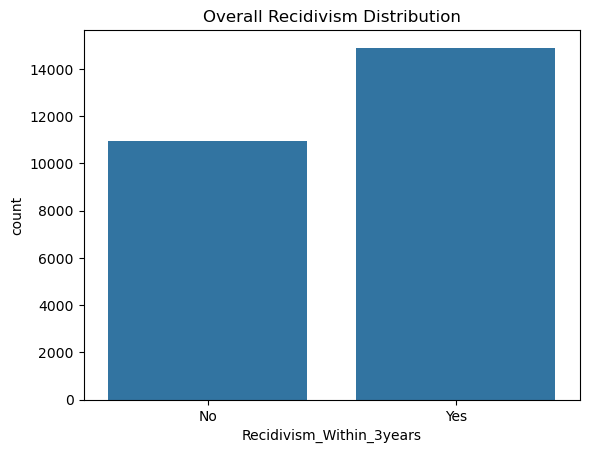

In [14]:
sns.countplot(x='Recidivism_Within_3years', data=df)
plt.title("Overall Recidivism Distribution")
plt.show()

In [15]:
# Age vs Recidivism
df['Age_at_Release'].describe()                          

count     25835
unique        7
top       23-27
freq       5176
Name: Age_at_Release, dtype: object

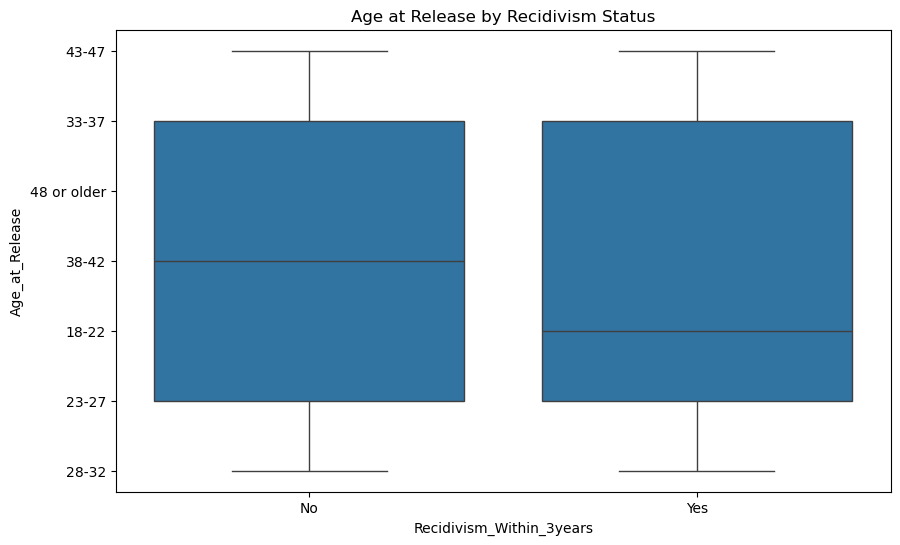

In [16]:
# Plot
plt.figure(figsize=(10, 6))
sns.boxplot(
    data = df,
    x = 'Recidivism_Within_3years',
    y = 'Age_at_Release'
)
plt.title('Age at Release by Recidivism Status')
plt.show()

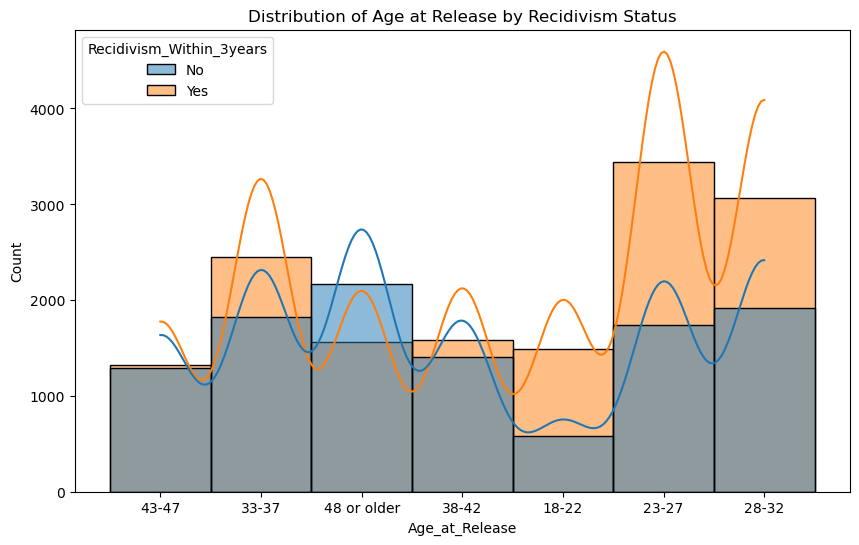

In [17]:
# hisplot
plt.figure(figsize=(10, 6))
sns.histplot(
    data = df,
    x = 'Age_at_Release',
    hue = 'Recidivism_Within_3years',
    kde = True,
    bins = 20
  )
plt.title('Distribution of Age at Release by Recidivism Status')
plt.show()

In [18]:
# Professional Improvement
'''
Instead of a histogram and box plot, I recommend we use a 100% stacked bar chart (or normalized bar chart) 
that shows the proportion of "Yes" and "No" within each age group.
'''
age_recid = pd.crosstab(
    df['Age_at_Release'],
    df['Recidivism_Within_3years'],
    normalize = 'index'    
) * 100
age_recid

Recidivism_Within_3years,No,Yes
Age_at_Release,,
18-22,28.025169,71.974831
23-27,33.578053,66.421947
28-32,38.538739,61.461261
33-37,42.753454,57.246546
38-42,47.043101,52.956899
43-47,49.389313,50.610687
48 or older,58.116448,41.883552


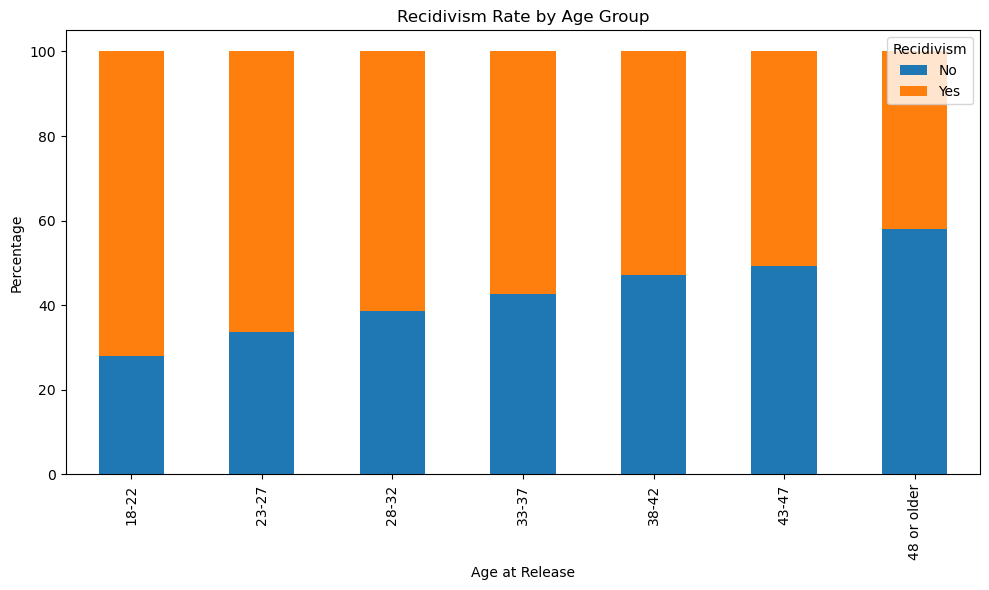

In [19]:
# plot age_recid
age_recid.plot(
    kind = 'bar',
    stacked = True,
    figsize = (10, 6)
)
plt.title('Recidivism Rate by Age Group')
plt.xlabel('Age at Release')
plt.ylabel('Percentage')
plt.legend(title = "Recidivism")
plt.tight_layout()
plt.show()

In [20]:
# Gender vs Recidivism
gender_recid = pd.crosstab(
    df['Gender'],
    df['Recidivism_Within_3years'],
    normalize = 'index'
) * 100
gender_recid

Recidivism_Within_3years,No,Yes
Gender,,
F,54.467951,45.532049
M,40.612317,59.387683


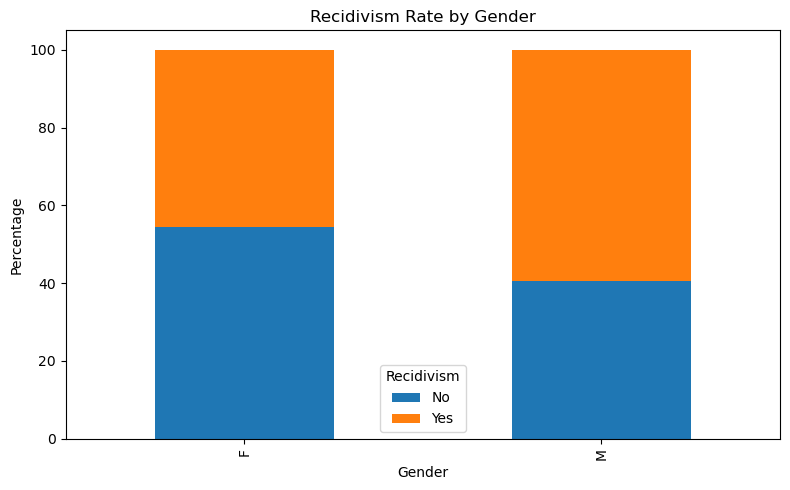

In [21]:
# Plot gender_recid
gender_recid.plot(
    kind = 'bar',
    stacked = True,
    figsize = (8, 5)
)
plt.title("Recidivism Rate by Gender")
plt.xlabel("Gender")
plt.ylabel("Percentage")
plt.legend(title="Recidivism")
plt.tight_layout()
plt.show()

In [22]:
# Race vs Recidivism
race_recid = pd.crosstab(
    df['Race'],
    df['Recidivism_Within_3years'],
    normalize = 'index'
) * 100
race_recid

Recidivism_Within_3years,No,Yes
Race,,
BLACK,41.314744,58.685256
WHITE,43.656716,56.343284


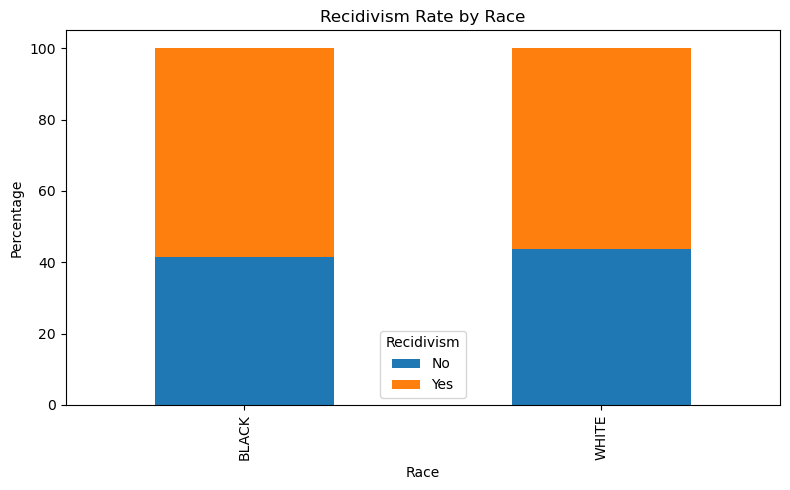

In [23]:
race_recid.plot(
    kind = 'bar',
    stacked = True,
    figsize = (8, 5)
)
plt.title("Recidivism Rate by Race")
plt.xlabel("Race")
plt.ylabel("Percentage")
plt.legend(title="Recidivism")
plt.tight_layout()
plt.show()

In [24]:
# Prior Convictions vs. Recidivism
df[['Prior_Conviction_Episodes_Felony',
    'Prior_Conviction_Episodes_Misd',
    'Prior_Conviction_Episodes_Viol',
    'Prior_Conviction_Episodes_Prop',
    'Prior_Conviction_Episodes_Drug']].describe()

,Prior_Conviction_Episodes_Felony,Prior_Conviction_Episodes_Misd,Prior_Conviction_Episodes_Viol,Prior_Conviction_Episodes_Prop,Prior_Conviction_Episodes_Drug
count,25835,25835,25835,25835,25835
unique,4,5,2,4,3
top,0,0,No,0,0
freq,7539,7819,17447,11198,12586


In [25]:
# Check the unique values
for col in [
    'Prior_Conviction_Episodes_Felony',
    'Prior_Conviction_Episodes_Misd',
    'Prior_Conviction_Episodes_Viol',
    'Prior_Conviction_Episodes_Prop',
    'Prior_Conviction_Episodes_Drug'
]:
    print(f"\n{col}")
    print(df[col].value_counts(dropna = False))


Prior_Conviction_Episodes_Felony
Prior_Conviction_Episodes_Felony
0            7539
1            6963
3 or more    6959
2            4374
Name: count, dtype: int64

Prior_Conviction_Episodes_Misd
Prior_Conviction_Episodes_Misd
0            7819
4 or more    5982
1            5387
2            3888
3            2759
Name: count, dtype: int64

Prior_Conviction_Episodes_Viol
Prior_Conviction_Episodes_Viol
No     17447
Yes     8388
Name: count, dtype: int64

Prior_Conviction_Episodes_Prop
Prior_Conviction_Episodes_Prop
0            11198
1             5896
3 or more     5435
2             3306
Name: count, dtype: int64

Prior_Conviction_Episodes_Drug
Prior_Conviction_Episodes_Drug
0            12586
2 or more     6760
1             6489
Name: count, dtype: int64


In [26]:
# Since the variables are of different types, instead of trying to analyse all five variables together, we will analyze them one at a time
# Felony Convictions
felony_recid = pd.crosstab(
    df['Prior_Conviction_Episodes_Felony'],
    df['Recidivism_Within_3years'],
    normalize = 'index'
) * 100
felony_recid

Recidivism_Within_3years,No,Yes
Prior_Conviction_Episodes_Felony,,
0,48.375116,51.624884
1,44.492317,55.507683
2,39.963420,60.036580
3 or more,35.033769,64.966231


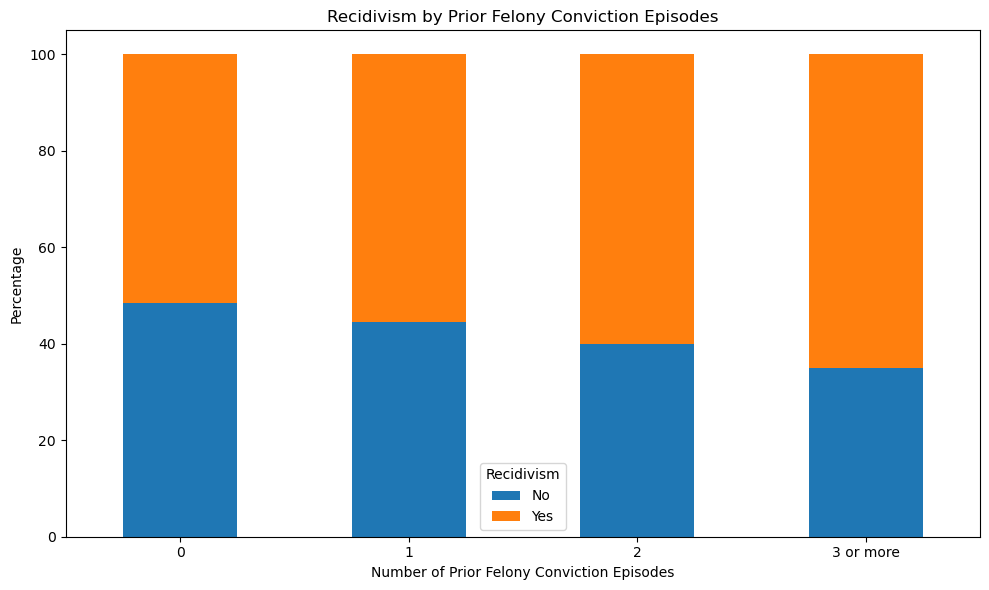

In [27]:
# felony_recid plot
felony_recid.plot(
    kind = 'bar',
    stacked = True,
    figsize = (10, 6)
)
plt.title('Recidivism by Prior Felony Conviction Episodes')
plt.xlabel('Number of Prior Felony Conviction Episodes')
plt.ylabel('Percentage')
plt.legend(title = "Recidivism")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [28]:
# Violent Convictions
violent_recid = pd.crosstab(
    df['Prior_Conviction_Episodes_Viol'],
    df['Recidivism_Within_3years'],
    normalize='index'
) * 100

violent_recid

Recidivism_Within_3years,No,Yes
Prior_Conviction_Episodes_Viol,,
No,43.910128,56.089872
Yes,38.984263,61.015737


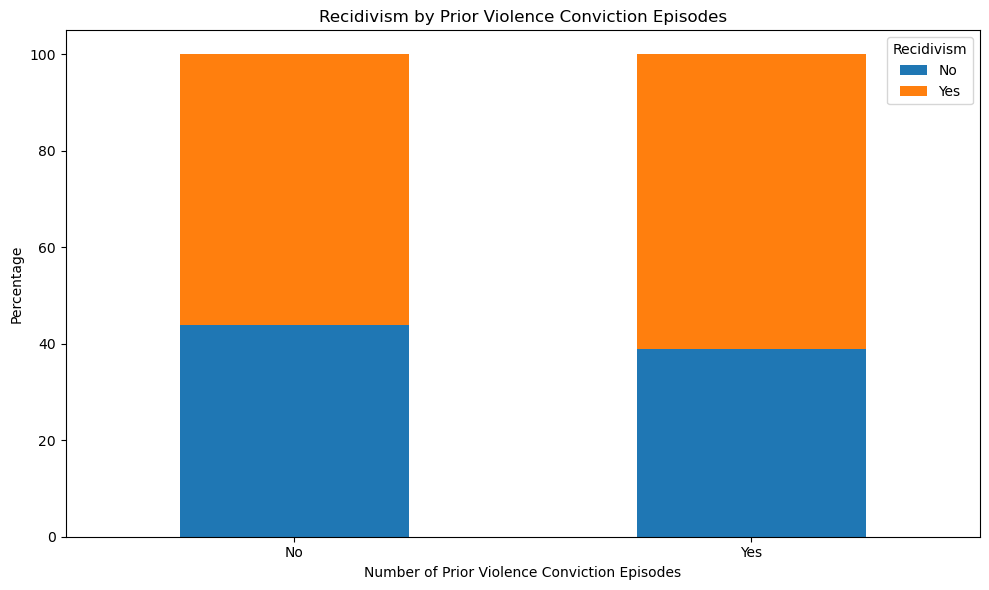

In [29]:
# plot
violent_recid.plot(
    kind = 'bar',
    stacked = True,
    figsize = (10, 6)
)
plt.title('Recidivism by Prior Violence Conviction Episodes')
plt.xlabel('Number of Prior Violence Conviction Episodes')
plt.ylabel('Percentage')
plt.legend(title = "Recidivism")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [30]:
# Prior Misdemeanor Conviction Episodes
misd_recid = pd.crosstab(
    df['Prior_Conviction_Episodes_Misd'],
    df['Recidivism_Within_3years'],
    normalize = 'index'
) * 100
misd_recid

Recidivism_Within_3years,No,Yes
Prior_Conviction_Episodes_Misd,,
0,54.201305,45.798695
1,42.676815,57.323185
2,39.120370,60.879630
3,36.389996,63.610004
4 or more,31.243731,68.756269


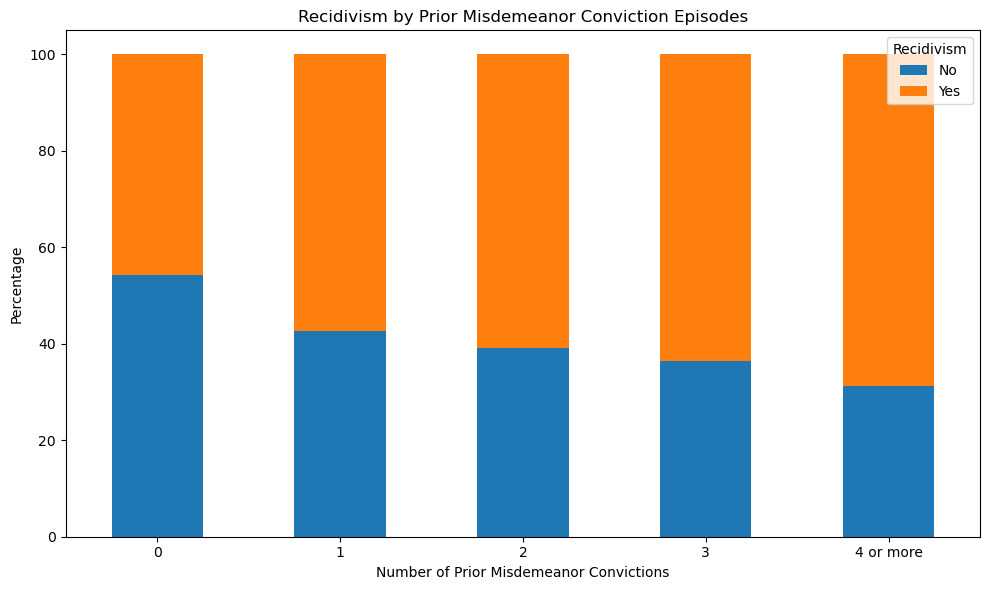

In [31]:
# misd_recid
misd_recid.plot(
    kind = 'bar',
    stacked = True,
    figsize = (10, 6)
)
plt.title('Recidivism by Prior Misdemeanor Conviction Episodes')
plt.xlabel('Number of Prior Misdemeanor Convictions')
plt.ylabel('Percentage')
plt.legend(title = 'Recidivism')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [32]:
# Prior Property Conviction Episodes
property_recid = pd.crosstab(
    df['Prior_Conviction_Episodes_Prop'],
    df['Recidivism_Within_3years'],
    normalize = 'index'
) * 100
property_recid

Recidivism_Within_3years,No,Yes
Prior_Conviction_Episodes_Prop,,
0,50.669762,49.330238
1,40.366350,59.633650
2,36.267393,63.732607
3 or more,30.873965,69.126035


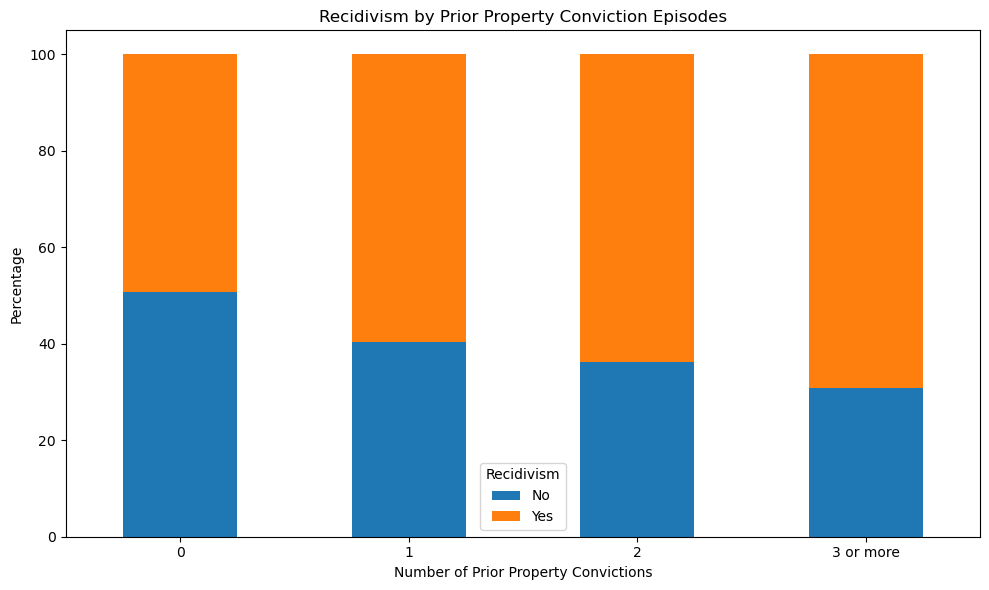

In [33]:
# property_recid plot
property_recid.plot(
    kind = 'bar',
    stacked = True,
    figsize = (10, 6)
)
plt.title('Recidivism by Prior Property Conviction Episodes')
plt.xlabel('Number of Prior Property Convictions')
plt.ylabel('Percentage')
plt.legend(title = 'Recidivism')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [34]:
# Prior Drug Conviction Episodes
drug_recid = pd.crosstab(
    df['Prior_Conviction_Episodes_Drug'],
    df['Recidivism_Within_3years'],
    normalize = 'index'
) * 100
drug_recid

Recidivism_Within_3years,No,Yes
Prior_Conviction_Episodes_Drug,,
0,45.582393,54.417607
1,40.191093,59.808907
2 or more,38.254438,61.745562


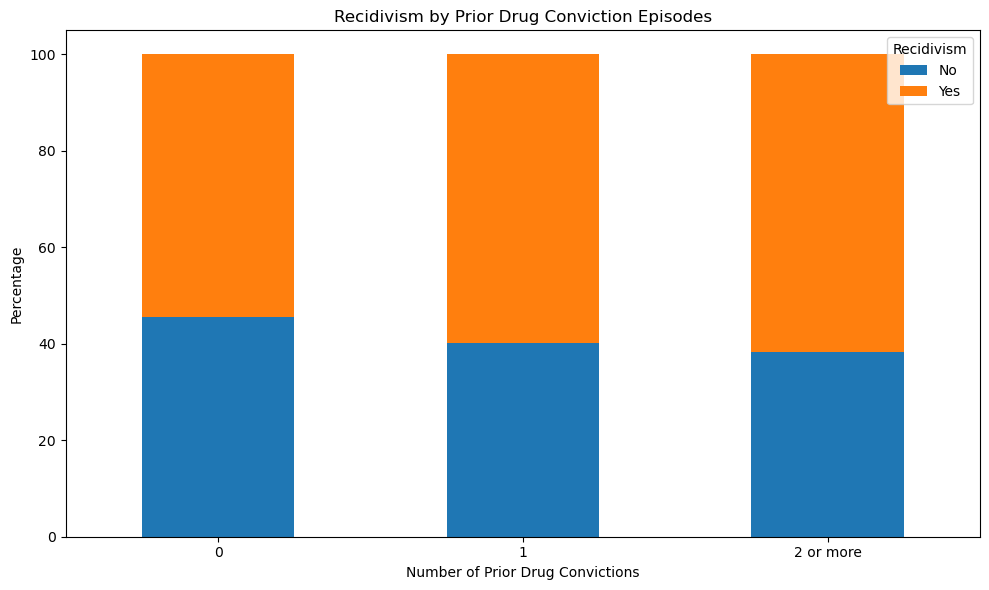

In [35]:
# drug_recid plot
drug_recid.plot(
    kind = 'bar',
    stacked = True,
    figsize = (10, 6)
)
plt.title('Recidivism by Prior Drug Conviction Episodes')
plt.xlabel('Number of Prior Drug Convictions')
plt.ylabel('Percentage')
plt.legend(title = 'Recidivism')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [36]:
# Prior Revocations
# Prior Revocations Parole
parole_recid = pd.crosstab(
    df['Prior_Revocations_Parole'],
    df['Recidivism_Within_3years'],
    normalize = 'index'
) * 100
parole_recid

Recidivism_Within_3years,No,Yes
Prior_Revocations_Parole,,
No,43.236880,56.763120
Yes,33.562475,66.437525


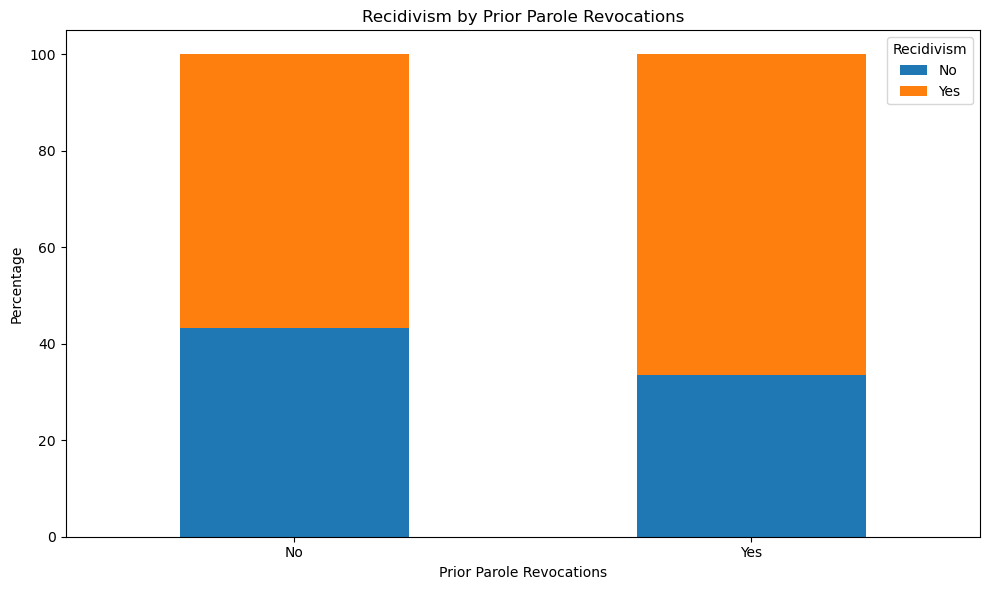

In [37]:
# revoke_parole_recid plot
parole_recid.plot(
    kind = 'bar',
    stacked = True,
    figsize = (10, 6)
)
plt.title('Recidivism by Prior Parole Revocations')
plt.xlabel('Prior Parole Revocations')
plt.ylabel('Percentage')
plt.legend(title = 'Recidivism')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [38]:
# Prior Probation Revocations
probation_recid = pd.crosstab(
    df['Prior_Revocations_Probation'],
    df['Recidivism_Within_3years'],
    normalize = 'index'
) * 100
probation_recid

Recidivism_Within_3years,No,Yes
Prior_Revocations_Probation,,
No,43.107667,56.892333
Yes,37.642686,62.357314


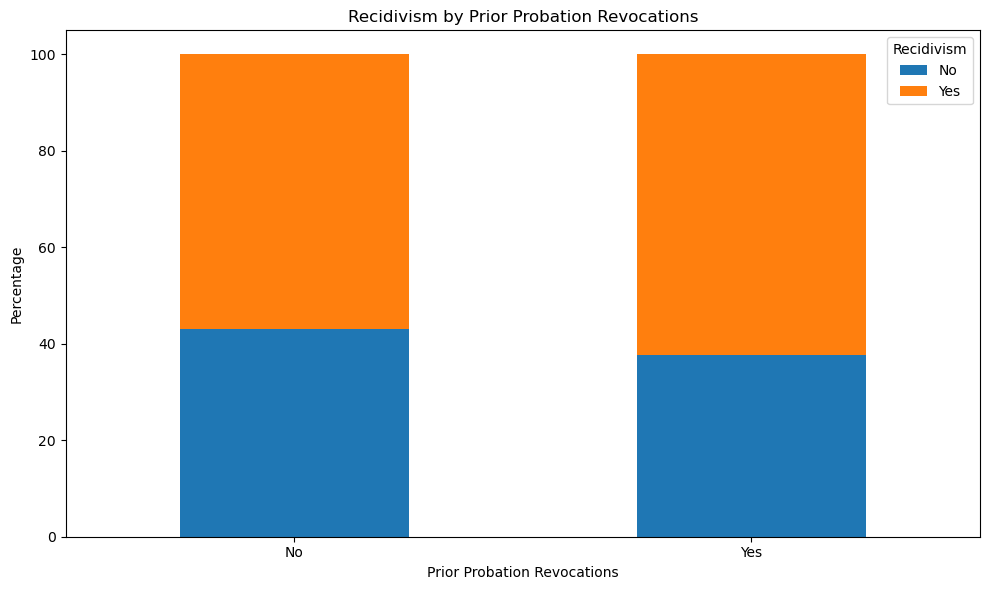

In [39]:
# Prior_Revocations_probation plot
probation_recid.plot(
    kind = 'bar',
    stacked = True,
    figsize = (10, 6)
)
plt.title('Recidivism by Prior Probation Revocations')
plt.xlabel('Prior Probation Revocations')
plt.ylabel('Percentage')
plt.legend(title = 'Recidivism')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [40]:
# Supervision Risk Score
df['Supervision_Risk_Score_First'].value_counts(dropna=False).sort_index()

Supervision_Risk_Score_First
1.0      751
2.0     1146
3.0     2069
4.0     2811
5.0     3554
6.0     3830
7.0     3574
8.0     2877
9.0     2513
10.0    2235
NaN      475
Name: count, dtype: int64

In [41]:
# Create crosstab for Supervision Risk Score
risk_recid = pd.crosstab(
    df['Supervision_Risk_Score_First'],
    df['Recidivism_Within_3years'],
    normalize = 'index'
) * 100
risk_recid

Recidivism_Within_3years,No,Yes
Supervision_Risk_Score_First,,
1.0,47.403462,52.596538
2.0,62.827225,37.172775
3.0,58.627356,41.372644
4.0,51.654216,48.345784
5.0,46.145189,53.854811
6.0,41.827676,58.172324
7.0,37.045327,62.954673
8.0,33.541884,66.458116
9.0,32.232392,67.767608


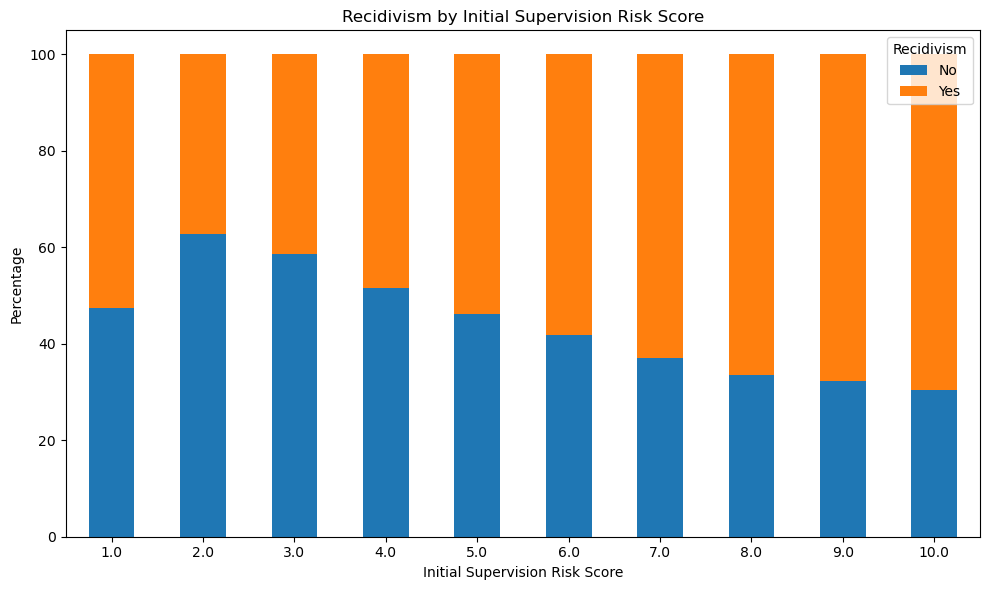

In [42]:
# Plot Supervision Risk Score
risk_recid.plot(
    kind = 'bar',
    stacked = True,
    figsize = (10, 6)
)
plt.title("Recidivism by Initial Supervision Risk Score")
plt.xlabel("Initial Supervision Risk Score")
plt.ylabel("Percentage")
plt.legend(title="Recidivism")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [43]:
# Understand the variables of Programme Attendance first
df['Program_Attendances'].describe()

count     25835
unique       11
top           0
freq      13686
Name: Program_Attendances, dtype: int64

In [44]:
df['Program_Attendances'].value_counts()

Program_Attendances
0             13686
10 or more     3231
6              2809
5              1142
1              1003
7               830
2               827
4               776
3               658
8               455
9               418
Name: count, dtype: int64

In [45]:
df['Program_Attendances'].unique()

array([6, 0, 7, 9, '10 or more', 2, 1, 5, 3, 4, 8], dtype=object)

In [46]:
attendance_order = [
    0, 1, 2, 3, 4, 5,
    6, 7, 8, 9, '10 or more'
]
attendance_recid = pd.crosstab(
    df['Program_Attendances'],
    df['Recidivism_Within_3years'],
    normalize = 'index'
).reindex(attendance_order) * 100
attendance_recid

Recidivism_Within_3years,No,Yes
Program_Attendances,,
0,40.851966,59.148034
1,32.303091,67.696909
2,34.340992,65.659008
3,33.890578,66.109422
4,40.077320,59.922680
5,39.316988,60.683012
6,47.454610,52.545390
7,43.012048,56.987952
8,39.120879,60.879121


In [47]:
# Change all variables to String
df['Program_Attendances'] = df['Program_Attendances'].astype(str)

In [48]:
df['Program_Attendances'].nunique()

11

In [49]:
df['Program_Attendances'].value_counts()

Program_Attendances
0             13686
10 or more     3231
6              2809
5              1142
1              1003
7               830
2               827
4               776
3               658
8               455
9               418
Name: count, dtype: int64

In [50]:
attendance_order = [
    '0', '1', '2', '3', '4', '5',
    '6', '7', '8', '9', '10 or more'
]
attendance_recid = pd.crosstab(
    df['Program_Attendances'],
    df['Recidivism_Within_3years'],
    normalize = 'index'
).reindex(attendance_order) * 100
attendance_recid

Recidivism_Within_3years,No,Yes
Program_Attendances,,
0,40.851966,59.148034
1,32.303091,67.696909
2,34.340992,65.659008
3,33.890578,66.109422
4,40.077320,59.922680
5,39.316988,60.683012
6,47.454610,52.545390
7,43.012048,56.987952
8,39.120879,60.879121


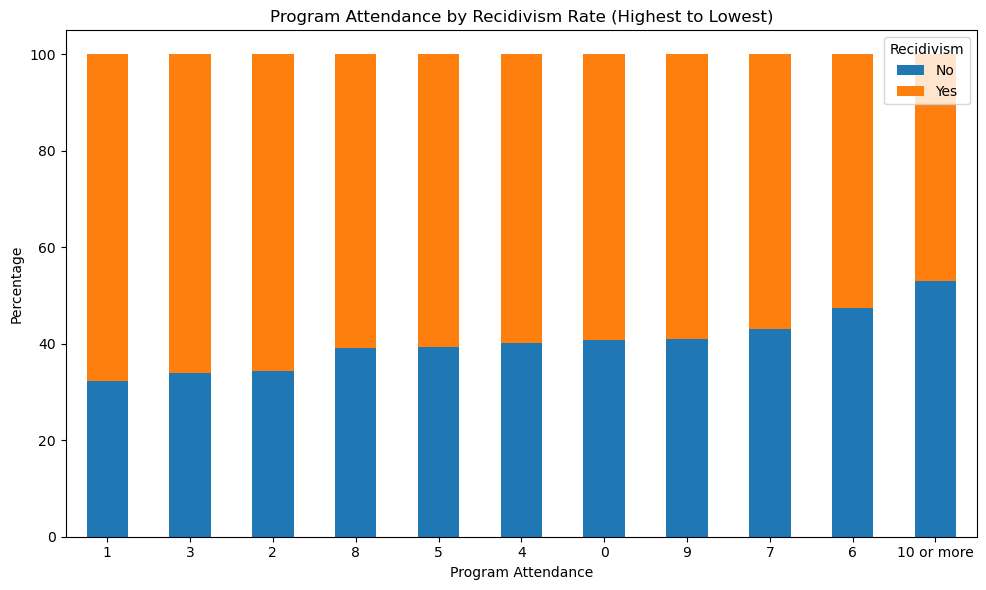

In [51]:
attendance_recid_sorted = attendance_recid.sort_values(by='Yes', ascending=False)
attendance_recid_sorted.plot(
    kind = 'bar',
    stacked = True,
    figsize = (10, 6)
    #normalize = 'index'
)
plt.title('Program Attendance by Recidivism Rate (Highest to Lowest)')
plt.xlabel('Program Attendance')
plt.ylabel('Percentage')
plt.xticks(rotation=0)
plt.tight_layout()
plt.legend(title='Recidivism')
plt.show()

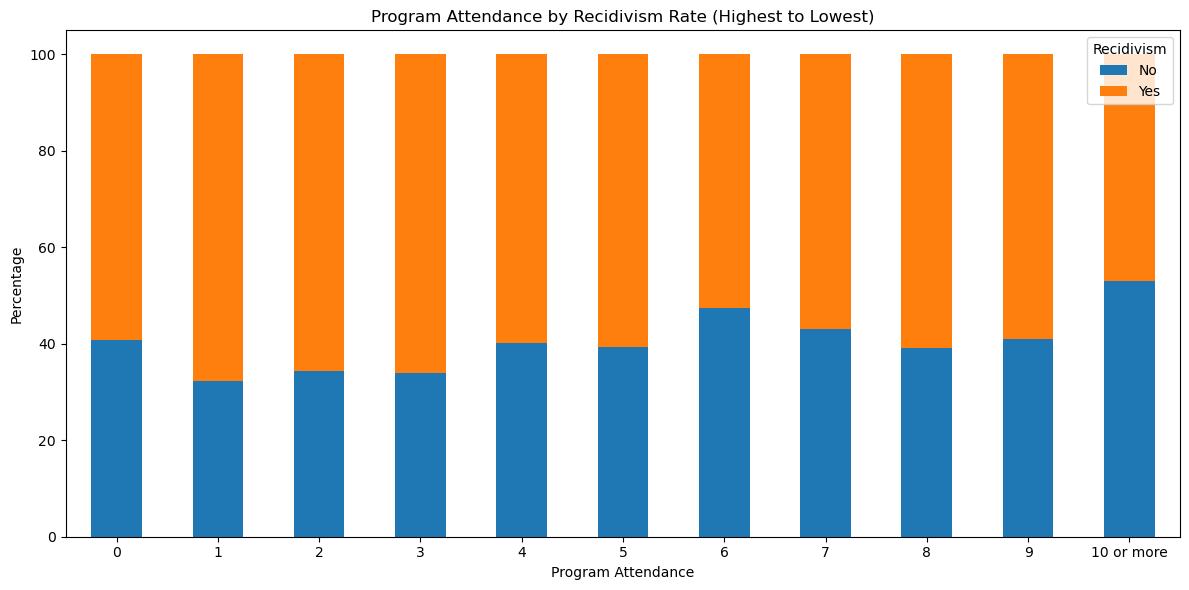

In [52]:
# sorting by recidivism makes one loose the natural progression of attendance.
# It is better to sort by program attendance
attendance_recid.plot(
    kind ='bar',
    stacked = True,
    figsize = (12, 6)
)
plt.title('Program Attendance by Recidivism Rate (Highest to Lowest)')
plt.xlabel('Program Attendance')
plt.ylabel('Percentage')
plt.xticks(rotation=0)
plt.tight_layout()
plt.legend(title='Recidivism')
plt.show()

In [53]:
# Check the number of people in each attendance category
df['Program_Attendances'].value_counts().sort_index()

Program_Attendances
0             13686
1              1003
10 or more     3231
2               827
3               658
4               776
5              1142
6              2809
7               830
8               455
9               418
Name: count, dtype: int64

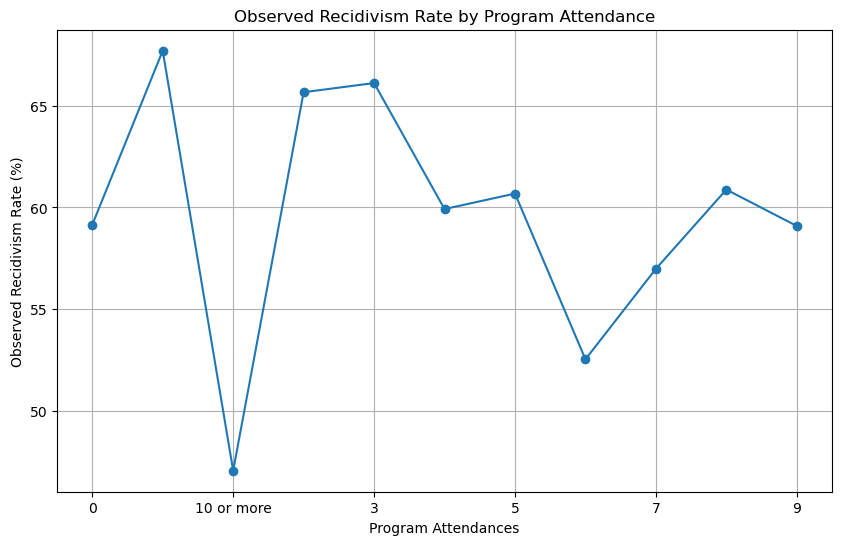

In [54]:
# plot by percentage
attendance_yes = attendance_recid['Yes'].sort_index()

attendance_yes.plot(
    kind='line',
    marker='o',
    figsize=(10,6)
)

plt.title("Observed Recidivism Rate by Program Attendance")
plt.xlabel("Program Attendances")
plt.ylabel("Observed Recidivism Rate (%)")
plt.grid(True)
plt.show()

In [55]:
df['Program_UnexcusedAbsences'].value_counts().sort_values(ascending=False)

Program_UnexcusedAbsences
0            20802
3 or more     2205
1             1682
2             1146
Name: count, dtype: int64

In [56]:
print(df['Program_UnexcusedAbsences'].nunique())

4


In [57]:
df['Program_UnexcusedAbsences'] = (df['Program_UnexcusedAbsences'].astype(str))

In [58]:
# the correct order
absence_order = ['0', '1', '2', '3 or more']

In [59]:
absence_recid = pd.crosstab(
    df['Program_UnexcusedAbsences'],
    df['Recidivism_Within_3years'],
    normalize = 'index'
).reindex(absence_order) * 100
absence_recid

Recidivism_Within_3years,No,Yes
Program_UnexcusedAbsences,,
0,43.774637,56.225363
1,37.514863,62.485137
2,33.595113,66.404887
3 or more,36.689342,63.310658


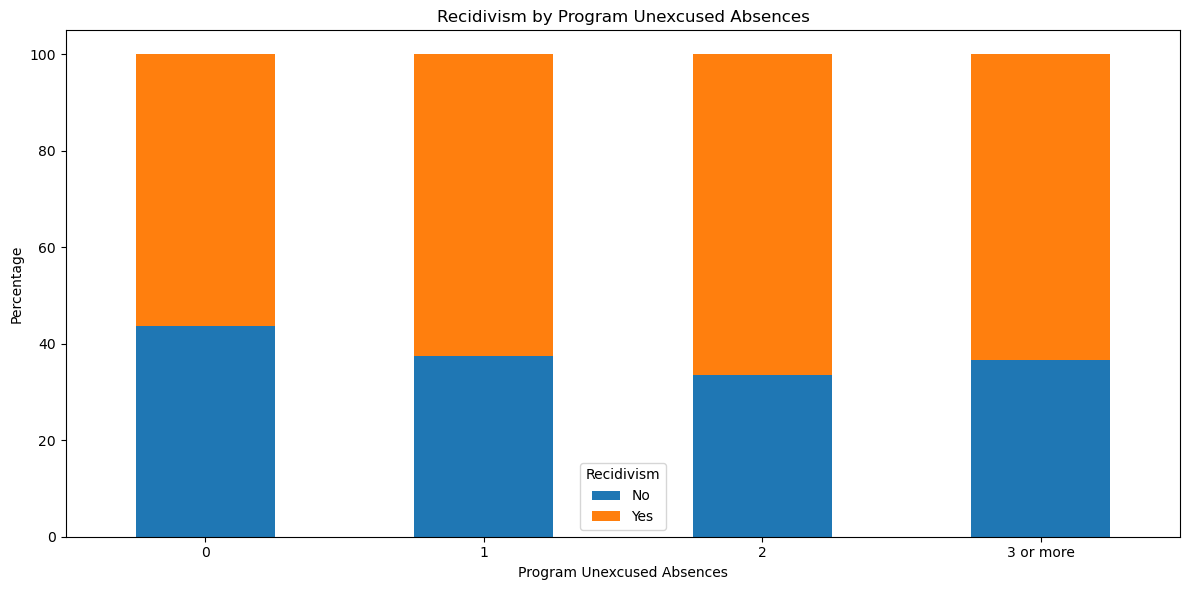

In [60]:
# plot absence_recid
absence_recid.plot(
    kind = 'bar',
    stacked = True,
    figsize = (12, 6)
)
plt.title("Recidivism by Program Unexcused Absences")
plt.xlabel("Program Unexcused Absences")
plt.ylabel("Percentage")
plt.xticks(rotation=0)
plt.legend(title="Recidivism")
plt.tight_layout()
plt.show()

In [61]:
# Create a reusable cleaning function instead of repeating the process in future
def convert_mixed_category_to_string(df, column):
    """
    Convert a mixed numeric/string categorical column to string.
    """
    df[column] = df[column].astype(str)
    return df

# e.g. convert_mixed_category_to_string(df, 'Program_Attendances')


In [62]:
df['Percent_Days_Employed'].describe()

count    25373.000000
mean         0.482331
std          0.425004
min          0.000000
25%          0.000000
50%          0.475728
75%          0.969325
max          1.000000
Name: Percent_Days_Employed, dtype: float64

In [63]:
df['Percent_Days_Employed'].head(20)

0     0.488562
1     0.425234
2     0.000000
3     1.000000
4     0.203562
5     0.674252
6     0.000000
7     0.469446
8     0.000000
9     0.359712
10    1.000000
11    0.000000
12    0.000000
13    1.000000
14    0.000000
15    0.338926
16    0.545852
17    0.452138
18    0.918575
19    0.794737
Name: Percent_Days_Employed, dtype: float64

In [64]:
df['Jobs_Per_Year'].describe()

count    25027.000000
mean         0.769295
std          0.813787
min          0.000000
25%          0.000000
50%          0.635217
75%          1.000000
max          8.000000
Name: Jobs_Per_Year, dtype: float64

In [65]:
df['Jobs_Per_Year'].value_counts().sort_index()

Jobs_Per_Year
0.000000    7784
0.136186       1
0.139143       1
0.139675       1
0.139943       1
            ... 
6.125786       1
6.393873       1
7.000000       1
7.098498       1
8.000000       1
Name: count, Length: 3615, dtype: int64

In [66]:
df['Employment_Exempt'].value_counts()

Employment_Exempt
No     22399
Yes     3436
Name: count, dtype: int64

In [67]:
df[['Percent_Days_Employed','Jobs_Per_Year','Employment_Exempt']].isnull().sum()

Percent_Days_Employed    462
Jobs_Per_Year            808
Employment_Exempt          0
dtype: int64

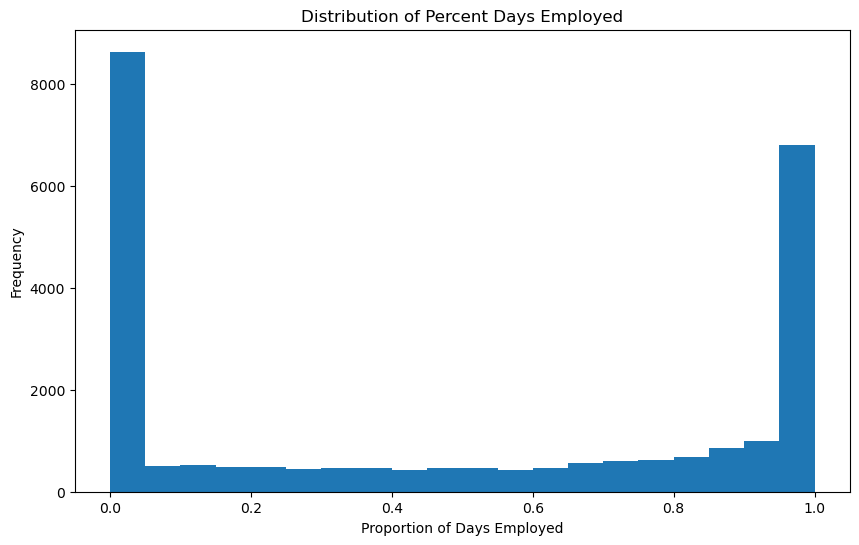

In [68]:
# Analysis of Percentage_Days_Employed
# This may be one of the strongest predictors in the entire dataset
# Inspection of its distribution:
plt.figure(figsize=(10, 6))
plt.hist(df['Percent_Days_Employed'], bins=20)
plt.title("Distribution of Percent Days Employed")
plt.xlabel('Proportion of Days Employed')
plt.ylabel('Frequency')
plt.show()

In [69]:
# Group Percent_Days_Employed bcos it is a continuous variable to make it esy to understand
bins = [-0.01, 0.0, 0.25, 0.50, 0.72, 1.0]
labels = ['0%', '1.25%', '26-50%', '51-75%', '76-100%']
df['Employment_Group'] = pd.cut(df['Percent_Days_Employed'],
                                bins = bins,
                                labels = labels)
df['Employment_Group'].head()

0     26-50%
1     26-50%
2         0%
3    76-100%
4      1.25%
Name: Employment_Group, dtype: category
Categories (5, object): ['0%' < '1.25%' < '26-50%' < '51-75%' < '76-100%']

In [70]:
# Now compute the recidivism percentage
employment_recid = pd.crosstab(
    df['Employment_Group'],
    df['Recidivism_Within_3years'],
    normalize = 'index'
) * 100
employment_recid

Recidivism_Within_3years,No,Yes
Employment_Group,,
0%,32.815368,67.184632
1.25%,20.243902,79.756098
26-50%,26.385224,73.614776
51-75%,41.732650,58.267350
76-100%,56.139161,43.860839


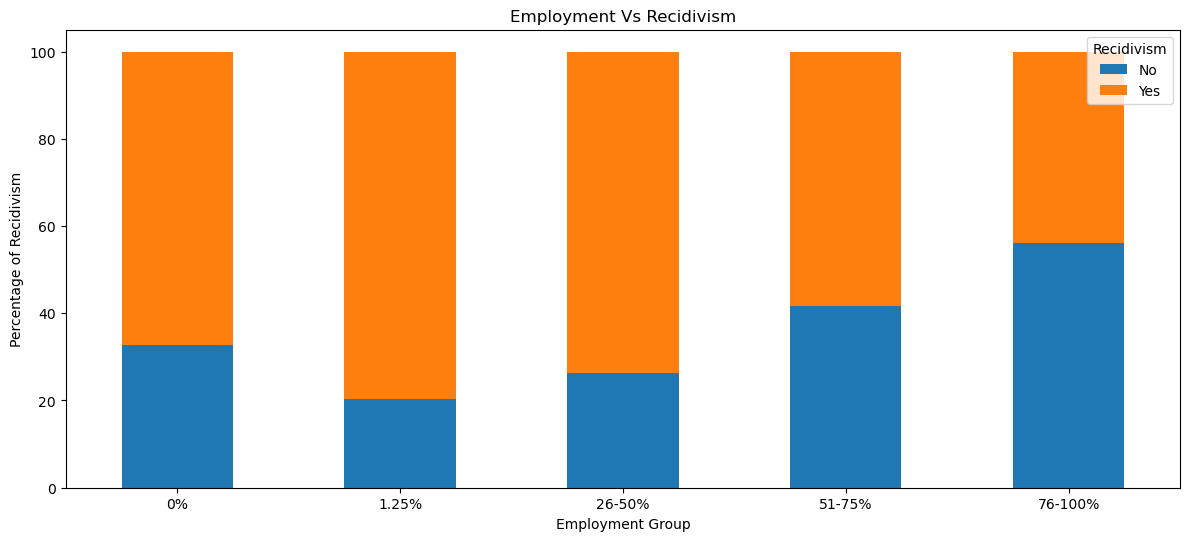

In [71]:
# Plot employment_recid
employment_recid.plot(
    kind = 'bar',
    stacked = True,
    figsize = (12, 6)
)
plt.title('Employment Vs Recidivism')
plt.xlabel('Employment Group')
plt.ylabel('Percentage of Recidivism')
plt.legend(title = 'Recidivism')
plt.tight_layout()
plt.xticks(rotation=0)
plt.show()

In [72]:
# Verify to see how many people fall into each employment category
df['Employment_Group'].value_counts().sort_index()

Employment_Group
0%          8173
1.25%       2460
26-50%      2274
51-75%      2147
76-100%    10319
Name: count, dtype: int64

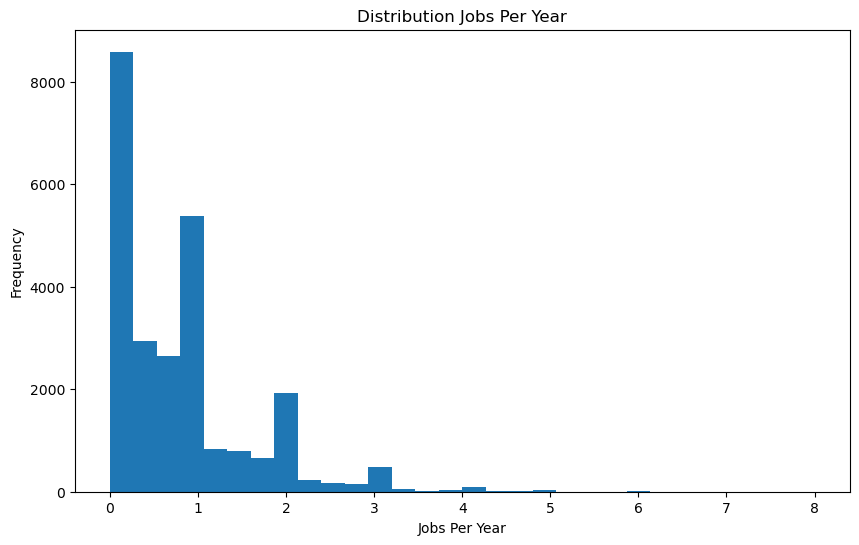

In [73]:
# Check the distribution
plt.figure(figsize=(10, 6))
plt.hist(df['Jobs_Per_Year'].dropna(), bins=30)
plt.title('Distribution Jobs Per Year')
plt.xlabel('Jobs Per Year')
plt.ylabel('Frequency')
plt.show()

In [74]:
# Create meaningful groups to eliminate arbitrary intervals. Use quartiles to keep the groups balanced.
df['Jobs_Group'] = pd.qcut(
    df['Jobs_Per_Year'],
    q=4,
    duplicates = 'drop'
)

df['Jobs_Group'].value_counts().sort_index()

Jobs_Group
(-0.001, 0.635]    12516
(0.635, 1.0]        6815
(1.0, 8.0]          5696
Name: count, dtype: int64

In [75]:
jobs_recid = pd.crosstab(
    df['Jobs_Group'],
    df['Recidivism_Within_3years'],
    normalize = 'index',
) * 100
jobs_recid

Recidivism_Within_3years,No,Yes
Jobs_Group,,
"(-0.001, 0.635]",39.309684,60.690316
"(0.635, 1.0]",37.608217,62.391783
"(1.0, 8.0]",46.348315,53.651685


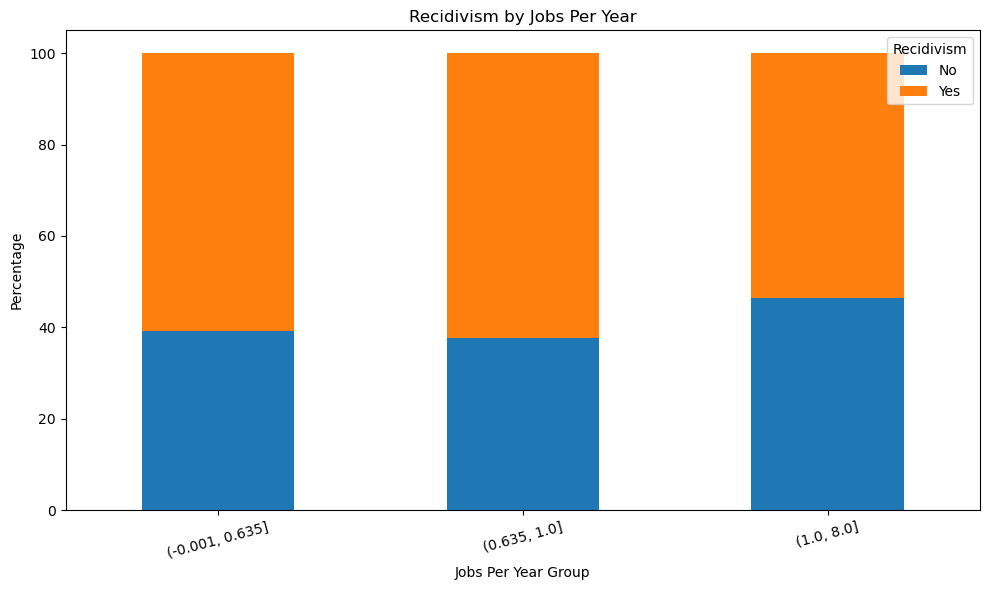

In [76]:
# plot
jobs_recid.plot(
    kind='bar',
    stacked=True,
    figsize=(10,6)
)

plt.title("Recidivism by Jobs Per Year")
plt.xlabel("Jobs Per Year Group")
plt.ylabel("Percentage")
plt.xticks(rotation=15)
plt.legend(title="Recidivism")
plt.tight_layout()
plt.show()

In [77]:
employment_exempt_recid = (
    pd.crosstab(
        df['Employment_Exempt'],
        df['Recidivism_Within_3years'],
        normalize='index'
    ) * 100
)

employment_exempt_recid

Recidivism_Within_3years,No,Yes
Employment_Exempt,,
No,41.336667,58.663333
Yes,48.661234,51.338766


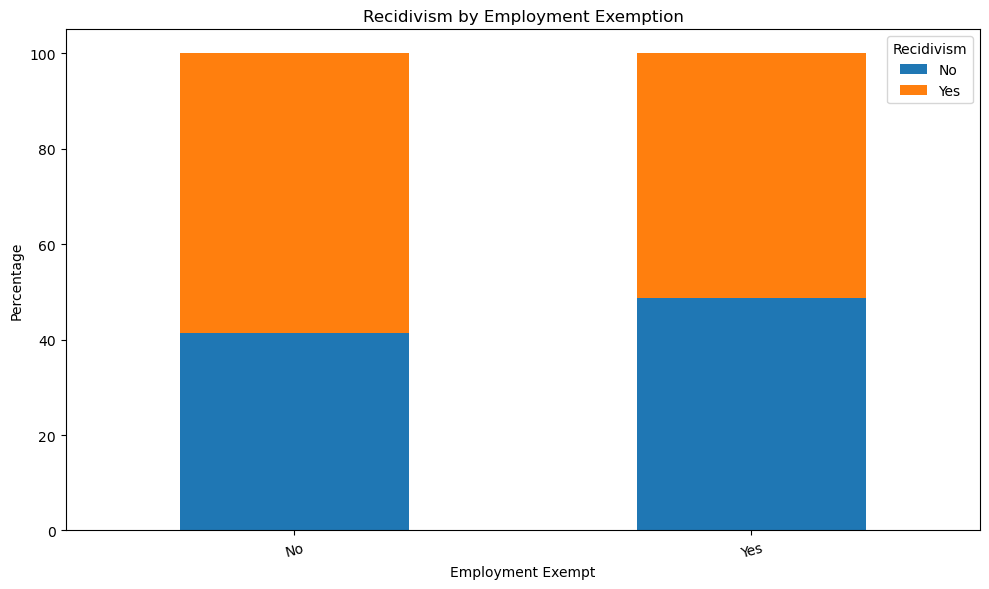

In [78]:
# plot
employment_exempt_recid.plot(
    kind = 'bar',
    stacked = True,
    figsize = (10, 6)
)
plt.title("Recidivism by Employment Exemption")
plt.xlabel("Employment Exempt")
plt.ylabel("Percentage")
plt.xticks(rotation=15)
plt.legend(title="Recidivism")
plt.tight_layout()
plt.show()

In [79]:
df['Avg_Days_per_DrugTest'].describe()

count    19732.000000
mean        93.890044
std        117.169847
min          0.500000
25%         28.837366
50%         55.424812
75%        110.333333
max       1088.500000
Name: Avg_Days_per_DrugTest, dtype: float64

In [80]:
df['DrugTests_THC_Positive'].describe()

count    20663.000000
mean         0.063350
std          0.138453
min          0.000000
25%          0.000000
50%          0.000000
75%          0.071429
max          1.000000
Name: DrugTests_THC_Positive, dtype: float64

In [81]:
df['DrugTests_Cocaine_Positive'].describe()

count    20663.000000
mean         0.013741
std          0.061233
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          1.000000
Name: DrugTests_Cocaine_Positive, dtype: float64

In [82]:
df['DrugTests_Meth_Positive'].describe()

count    20663.000000
mean         0.012890
std          0.060581
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          1.000000
Name: DrugTests_Meth_Positive, dtype: float64

In [83]:
df['DrugTests_Other_Positive'].describe()

count    20663.00000
mean         0.00755
std          0.04115
min          0.00000
25%          0.00000
50%          0.00000
75%          0.00000
max          1.00000
Name: DrugTests_Other_Positive, dtype: float64

In [84]:
drug_cols = [
    'Avg_Days_per_DrugTest',
    'DrugTests_THC_Positive',
    'DrugTests_Cocaine_Positive',
    'DrugTests_Meth_Positive',
    'DrugTests_Other_Positive'
]

df[drug_cols].head(20)

,Avg_Days_per_DrugTest,DrugTests_THC_Positive,DrugTests_Cocaine_Positive,DrugTests_Meth_Positive,DrugTests_Other_Positive
0,612.000000,0.000000,0.0,0.000000,0.000000
1,35.666667,0.000000,0.0,0.000000,0.000000
2,93.666667,0.333333,0.0,0.166667,0.000000
3,25.400000,0.000000,0.0,0.000000,0.000000
4,23.117647,0.000000,0.0,0.058824,0.000000
5,474.600000,0.000000,0.0,0.000000,0.000000
6,238.500000,0.000000,0.0,0.000000,0.000000
7,34.775000,0.000000,0.0,0.000000,0.000000
8,NaN,NaN,NaN,NaN,NaN
9,27.800000,0.000000,0.0,0.000000,0.000000


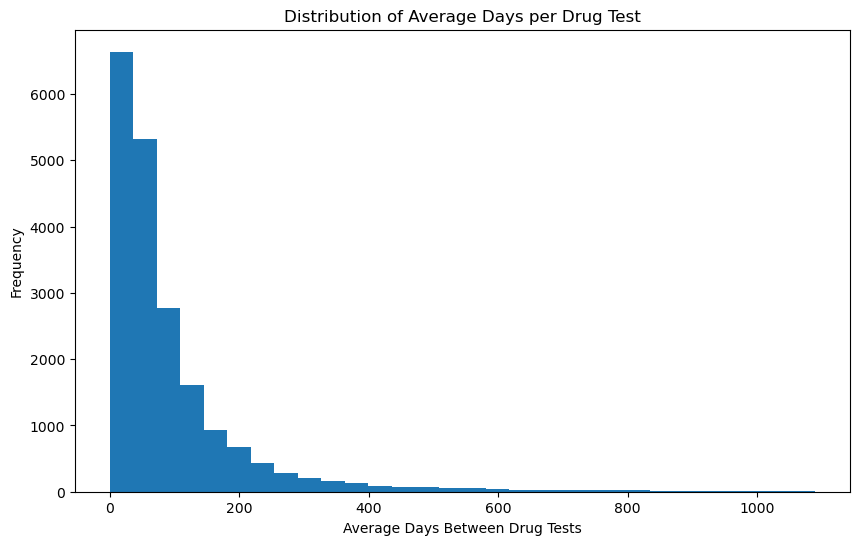

In [85]:
# Analysis of Avg_Days-per_DrugTest
plt.figure(figsize=(10,6))

plt.hist(df['Avg_Days_per_DrugTest'].dropna(), bins=30)

plt.title("Distribution of Average Days per Drug Test")
plt.xlabel("Average Days Between Drug Tests")
plt.ylabel("Frequency")

plt.show()

In [86]:
# The disribution is seriously skewed, we can not use equal width bins (e.g., 0-200, 200-400
# Why? Almost everyone would end up in the first bin, making the others sparse and less informative.
# Instead, let's use quartiles so that each group contains roughly similar numbers of people.
df['DrugTestInterval_Group'] = pd.qcut(
    df['Avg_Days_per_DrugTest'],
    q=4,
    duplicates='drop'
)

df['DrugTestInterval_Group'].value_counts().sort_index()

DrugTestInterval_Group
(0.499, 28.837]      4933
(28.837, 55.425]     4933
(55.425, 110.333]    4938
(110.333, 1088.5]    4928
Name: count, dtype: int64

In [87]:
drug_interval_recid = (
    pd.crosstab(
        df['DrugTestInterval_Group'],
        df['Recidivism_Within_3years'],
        normalize='index'
    ) * 100
)

drug_interval_recid

Recidivism_Within_3years,No,Yes
DrugTestInterval_Group,,
"(0.499, 28.837]",38.414758,61.585242
"(28.837, 55.425]",44.293533,55.706467
"(55.425, 110.333]",45.524504,54.475496
"(110.333, 1088.5]",41.051136,58.948864


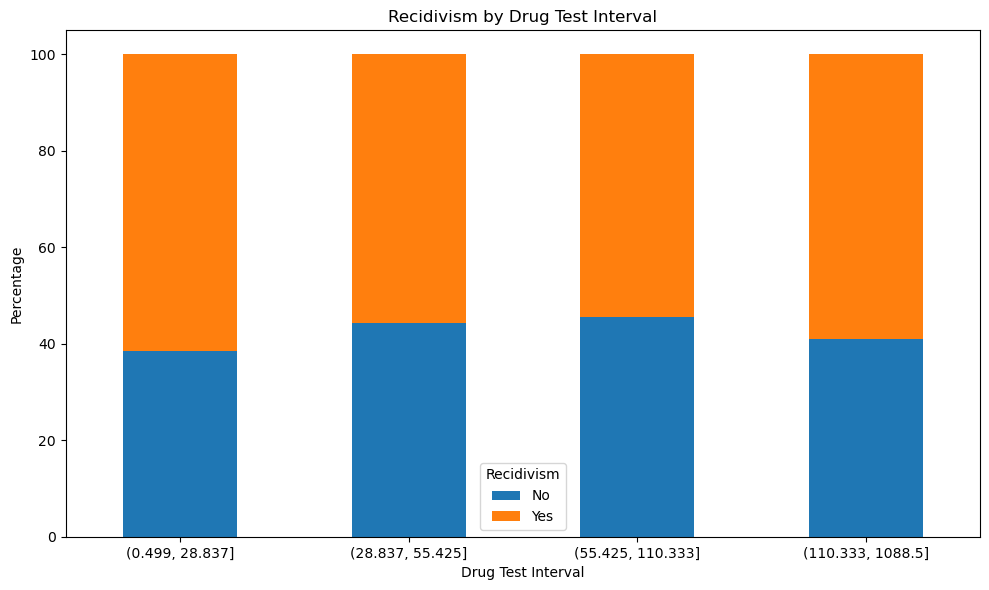

In [88]:
# plot drug_interval_recid
drug_interval_recid.plot(
    kind = 'bar',
    stacked = True,
    figsize = (10, 6)
)
plt.title("Recidivism by Drug Test Interval")
plt.xlabel("Drug Test Interval")
plt.ylabel("Percentage")
plt.xticks(rotation=0)
plt.legend(title="Recidivism")
plt.tight_layout()
plt.show()

In [89]:
# Analysis of THC Positive Rate
bins = [-0.01, 0, 0.25, 0.50, 0.75, 1]

labels = [
    '0%',
    '1-25%',
    '26-50%',
    '51-75%',
    '76-100%'
]

df['THC_Group'] = pd.cut(
    df['DrugTests_THC_Positive'],
    bins=bins,
    labels=labels
)
# Calculation
thc_recid = (
    pd.crosstab(
        df['THC_Group'],
        df['Recidivism_Within_3years'],
        normalize='index'
    ) * 100
)

thc_recid

Recidivism_Within_3years,No,Yes
THC_Group,,
0%,48.368604,51.631396
1-25%,41.798419,58.201581
26-50%,20.347003,79.652997
51-75%,15.517241,84.482759
76-100%,25.000000,75.000000


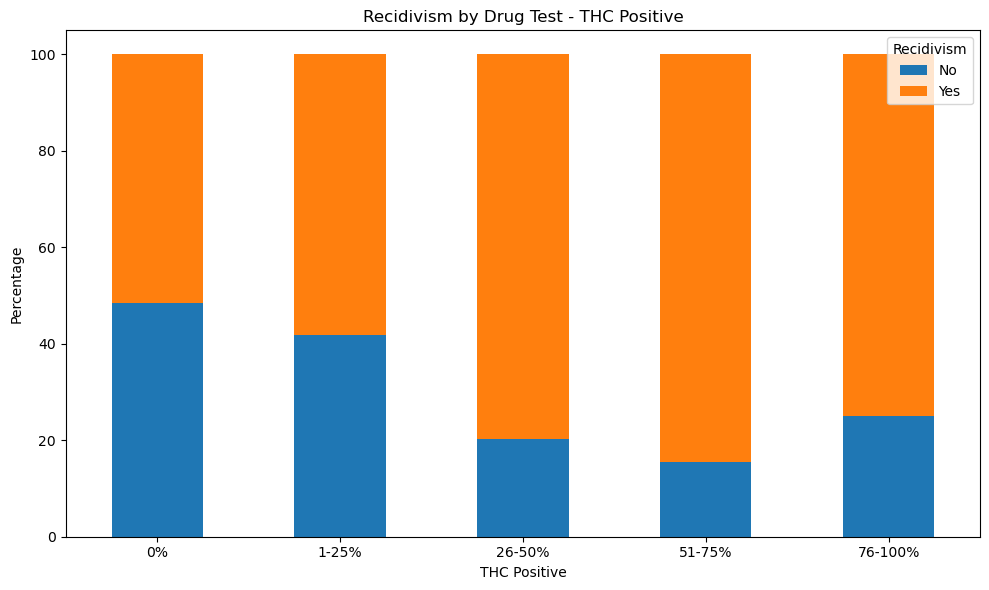

In [90]:
# plot thc_recid
thc_recid.plot(
    kind = 'bar',
    stacked = True,
    figsize = (10, 6)
)
plt.title("Recidivism by Drug Test - THC Positive")
plt.xlabel("THC Positive")
plt.ylabel("Percentage")
plt.xticks(rotation=0)
plt.legend(title="Recidivism")
plt.tight_layout()
plt.show()

In [91]:
# Check why 76-100% group drop
df['THC_Group'].value_counts().sort_index()

THC_Group
0%         14129
1-25%       5060
26-50%      1268
51-75%        58
76-100%      148
Name: count, dtype: int64

In [92]:
# *** the last two groups in THC_Group are simply too small to draw strong conclusions about the exact percentages.

In [93]:
# Analysis of Cocaine Positive Rate
bins = [-0.01, 0, 0.25, 0.50, 0.75, 1]

labels = [
    '0%',
    '1-25%',
    '26-50%',
    '51-75%',
    '76-100%'
]

df['Cocaine_Group'] = pd.cut(
    df['DrugTests_Cocaine_Positive'],
    bins=bins,
    labels=labels
)
# Calculation
cocaine_recid = (
    pd.crosstab(
        df['Cocaine_Group'],
        df['Recidivism_Within_3years'],
        normalize='index'
    ) * 100
)

cocaine_recid

Recidivism_Within_3years,No,Yes
Cocaine_Group,,
0%,45.186054,54.813946
1-25%,43.082524,56.917476
26-50%,25.104603,74.895397
51-75%,20.000000,80.000000
76-100%,46.153846,53.846154


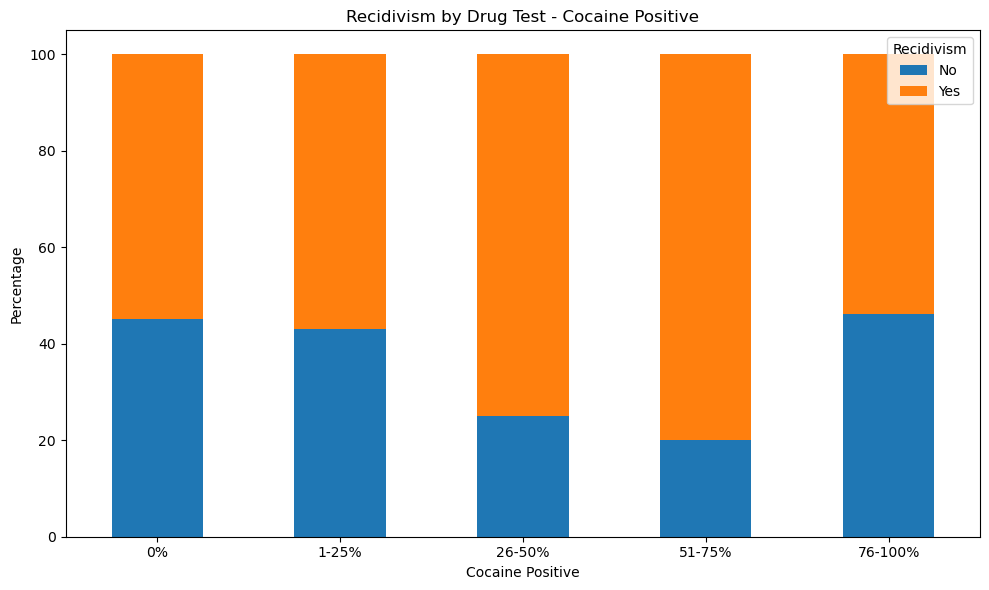

In [94]:
# plot cocaine_recid
cocaine_recid.plot(
    kind = 'bar',
    stacked = True,
    figsize = (10, 6)
)
plt.title("Recidivism by Drug Test - Cocaine Positive")
plt.xlabel("Cocaine Positive")
plt.ylabel("Percentage")
plt.xticks(rotation=0)
plt.legend(title="Recidivism")
plt.tight_layout()
plt.show()

In [95]:
# Investigate why there is drop in 76-100% group of Cocaine Positive
df['Cocaine_Group'].value_counts().sort_index()

Cocaine_Group
0%         18758
1-25%       1648
26-50%       239
51-75%         5
76-100%       13
Name: count, dtype: int64

In [96]:
# Analysis of Meth Positive Rate
bins = [-0.01, 0, 0.25, 0.50, 0.75, 1]

labels = [
    '0%',
    '1-25%',
    '26-50%',
    '51-75%',
    '76-100%'
]

df['Meth_Group'] = pd.cut(
    df['DrugTests_Meth_Positive'],
    bins=bins,
    labels=labels
)
# Calculation
meth_recid = (
    pd.crosstab(
        df['Meth_Group'],
        df['Recidivism_Within_3years'],
        normalize='index'
    ) * 100
)

meth_recid

Recidivism_Within_3years,No,Yes
Meth_Group,,
0%,45.994846,54.005154
1-25%,35.679214,64.320786
26-50%,15.476190,84.523810
51-75%,0.000000,100.000000
76-100%,18.181818,81.818182


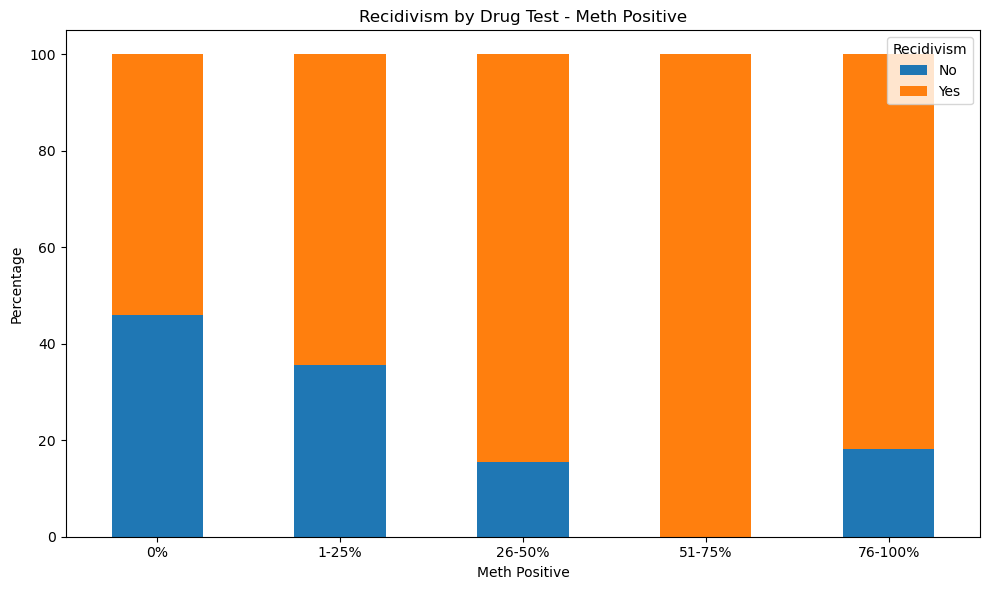

In [97]:
# plot meth_recid
meth_recid.plot(
    kind = 'bar',
    stacked = True,
    figsize = (10, 6)
)
plt.title("Recidivism by Drug Test - Meth Positive")
plt.xlabel("Meth Positive")
plt.ylabel("Percentage")
plt.xticks(rotation=0)
plt.legend(title="Recidivism")
plt.tight_layout()
plt.show()

In [98]:
df['Meth_Group'].value_counts().sort_index()

Meth_Group
0%         18626
1-25%       1833
26-50%       168
51-75%         3
76-100%       33
Name: count, dtype: int64

In [99]:
# Analysis of Other_Positive Rate
bins = [-0.01, 0, 0.25, 0.50, 0.75, 1]

labels = [
    '0%',
    '1-25%',
    '26-50%',
    '51-75%',
    '76-100%'
]

df['OtherDrugs_Group'] = pd.cut(
    df['DrugTests_Other_Positive'],
    bins=bins,
    labels=labels
)
# Calculation
other_drugs_recid = (
    pd.crosstab(
        df['OtherDrugs_Group'],
        df['Recidivism_Within_3years'],
        normalize='index'
    ) * 100
)

other_drugs_recid

Recidivism_Within_3years,No,Yes
OtherDrugs_Group,,
0%,44.993994,55.006006
1-25%,43.335659,56.664341
26-50%,17.647059,82.352941
51-75%,20.000000,80.000000
76-100%,40.000000,60.000000


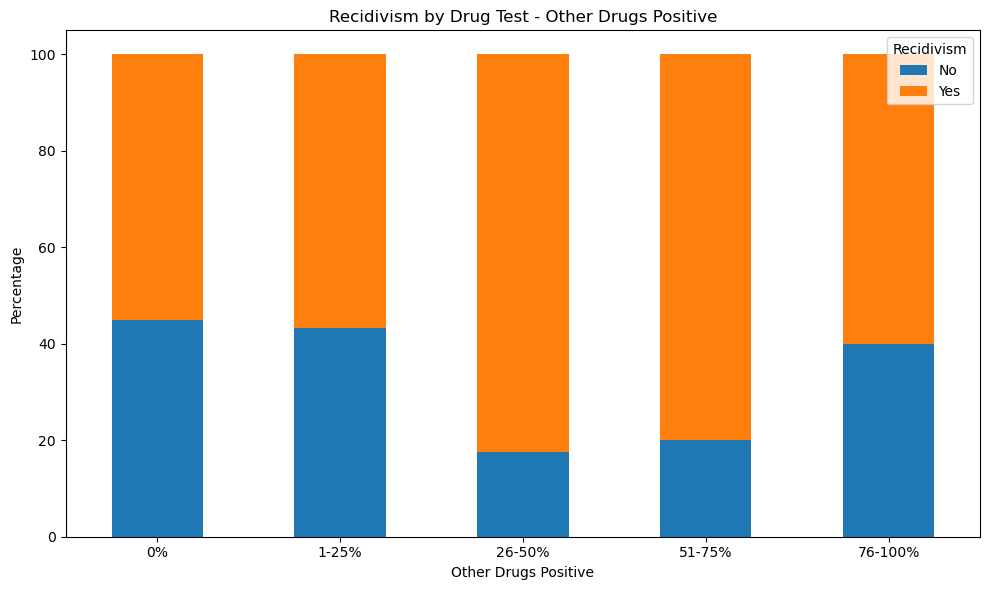

In [100]:
# plot other_drugs_recid
other_drugs_recid.plot(
    kind = 'bar',
    stacked = True,
    figsize = (10, 6)
)
plt.title("Recidivism by Drug Test - Other Drugs Positive")
plt.xlabel("Other Drugs Positive")
plt.ylabel("Percentage")
plt.xticks(rotation=0)
plt.legend(title="Recidivism")
plt.tight_layout()
plt.show()

In [101]:
# Check OtherDrugs_Group sample size
df['OtherDrugs_Group'].value_counts().sort_index()

OtherDrugs_Group
0%         19147
1-25%       1433
26-50%        68
51-75%         5
76-100%       10
Name: count, dtype: int64

## PREDICTIVE ANALYTICS

In [102]:
# Data inspection
df.dtypes

ID                           int64
Gender                      object
Race                        object
Age_at_Release              object
Residence_PUMA               int64
                            ...   
DrugTestInterval_Group    category
THC_Group                 category
Cocaine_Group             category
Meth_Group                category
OtherDrugs_Group          category
Length: 61, dtype: object

In [103]:
# Check and remove unimportant variable
df[['_v1','_v2','_v3','_v4']].head(10)

,_v1,_v2,_v3,_v4
0,4,No,No,No
1,5 or more,Yes,Yes,Yes
2,5 or more,No,Yes,No
3,3,No,No,No
4,3,No,No,No
5,0,No,No,No
6,5 or more,Yes,No,Yes
7,5 or more,Yes,No,No
8,3,Yes,No,No
9,5 or more,Yes,Yes,Yes


In [104]:
df[['_v1','_v2','_v3','_v4']].describe(include='all')

,_v1,_v2,_v3,_v4
count,25835,25835,25835,25835
unique,6,2,2,2
top,0,No,No,No
freq,6699,17367,23726,22380


In [105]:
# Check the target variable
df['Recidivism_Within_3years'].value_counts()

Recidivism_Within_3years
Yes    14904
No     10931
Name: count, dtype: int64

In [106]:
df['Recidivism_Within_3years_Status'] = df['Recidivism_Within_3years'] == 'Yes'
df['Recidivism_Within_3years_Status'].value_counts()

Recidivism_Within_3years_Status
True     14904
False    10931
Name: count, dtype: int64

In [107]:
# Check missing values
df.isnull().sum().head(60).sort_values(ascending=False)

Avg_Days_per_DrugTest               6103
DrugTestInterval_Group              6103
DrugTests_Other_Positive            5172
DrugTests_THC_Positive              5172
DrugTests_Cocaine_Positive          5172
DrugTests_Meth_Positive             5172
Meth_Group                          5172
Cocaine_Group                       5172
THC_Group                           5172
Prison_Offense                      3277
Gang_Affiliated                     3167
Supervision_Level_First             1720
Jobs_Per_Year                        808
Jobs_Group                           808
Supervision_Risk_Score_First         475
Employment_Group                     462
Percent_Days_Employed                462
Program_Attendances                    0
Program_UnexcusedAbsences              0
Delinquency_Reports                    0
Violations_MoveWithoutPermission       0
Residence_Changes                      0
Violations_Instruction                 0
Violations_FailToReport                0
Employment_Exemp

In [108]:
# Identify feature Types
categorical_cols = df.select_dtypes(include='object').columns.tolist()

numerical_cols = df.select_dtypes(exclude='object').columns.tolist()

print('These are categorical columns: ',categorical_cols)
print()
print('These are numerical columns: ',numerical_cols)

These are categorical columns:  ['Gender', 'Race', 'Age_at_Release', 'Gang_Affiliated', 'Supervision_Level_First', 'Education_Level', 'Dependents', 'Prison_Offense', 'Prison_Years', 'Prior_Arrest_Episodes_Felony', 'Prior_Arrest_Episodes_Misd', 'Prior_Arrest_Episodes_Violent', 'Prior_Arrest_Episodes_Property', 'Prior_Arrest_Episodes_Drug', '_v1', 'Prior_Arrest_Episodes_DVCharges', 'Prior_Arrest_Episodes_GunCharges', 'Prior_Conviction_Episodes_Felony', 'Prior_Conviction_Episodes_Misd', 'Prior_Conviction_Episodes_Viol', 'Prior_Conviction_Episodes_Prop', 'Prior_Conviction_Episodes_Drug', '_v2', '_v3', '_v4', 'Prior_Revocations_Parole', 'Prior_Revocations_Probation', 'Condition_MH_SA', 'Condition_Cog_Ed', 'Condition_Other', 'Violations_ElectronicMonitoring', 'Violations_Instruction', 'Violations_FailToReport', 'Violations_MoveWithoutPermission', 'Delinquency_Reports', 'Program_Attendances', 'Program_UnexcusedAbsences', 'Residence_Changes', 'Employment_Exempt', 'Recidivism_Within_3years', 'R

In [109]:
# Understand this variable before decding on it
df['Training_Sample'].value_counts()

Training_Sample
1    18028
0     7807
Name: count, dtype: int64

In [110]:
# Create a list of variables to be discarded
drop_cols = [
    'ID',
    '_v1',
    '_v2',
    '_v3',
    '_v4',
    'Training_Sample',
    'Recidivism_Arrest_Year1',
    'Recidivism_Arrest_Year2',
    'Recidivism_Arrest_Year3'
]

In [111]:
# Remove the engineered EDA variables and leave the original variables
group_cols = [
    'Employment_Group',
    'Jobs_Group',
    'DrugTestInterval_Group',
    'THC_Group',
    'Cocaine_Group',
    'Meth_Group',
    'OtherDrugs_Group'
]

In [112]:
# Save df to your folder
df.to_excel(r'C:\Users\USER\OneDrive\Desktop\My Briefcase\Full stack analyst\World Prisons\Recidivism\resources\datasets\df.xlsx')

In [113]:
# import necessary libraries
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

In [114]:
# Create the cleaned dataframe
drop_cols = [
    'ID',
    '_v1',
    '_v2',
    '_v3',
    '_v4',
    'Training_Sample',
    'Recidivism_Arrest_Year1',
    'Recidivism_Arrest_Year2',
    'Recidivism_Arrest_Year3',
    'Employment_Group',
    'Jobs_Group',
    'DrugTestInterval_Group',
    'THC_Group',
    'Cocaine_Group',
    'Meth_Group',
    'OtherDrugs_Group'
]

model_df = df.drop(columns=drop_cols)

In [115]:
# Save model_df as cleaned into your folder
model_df.to_excel(r'C:\Users\USER\OneDrive\Desktop\My Briefcase\Full stack analyst\World Prisons\Recidivism\resources\Recidivism_Cleaned.xlsx')

In [116]:
# Check
print(model_df.shape)
print(model_df.columns)

(25835, 46)
Index(['Gender', 'Race', 'Age_at_Release', 'Residence_PUMA', 'Gang_Affiliated',
       'Supervision_Risk_Score_First', 'Supervision_Level_First',
       'Education_Level', 'Dependents', 'Prison_Offense', 'Prison_Years',
       'Prior_Arrest_Episodes_Felony', 'Prior_Arrest_Episodes_Misd',
       'Prior_Arrest_Episodes_Violent', 'Prior_Arrest_Episodes_Property',
       'Prior_Arrest_Episodes_Drug', 'Prior_Arrest_Episodes_DVCharges',
       'Prior_Arrest_Episodes_GunCharges', 'Prior_Conviction_Episodes_Felony',
       'Prior_Conviction_Episodes_Misd', 'Prior_Conviction_Episodes_Viol',
       'Prior_Conviction_Episodes_Prop', 'Prior_Conviction_Episodes_Drug',
       'Prior_Revocations_Parole', 'Prior_Revocations_Probation',
       'Condition_MH_SA', 'Condition_Cog_Ed', 'Condition_Other',
       'Violations_ElectronicMonitoring', 'Violations_Instruction',
       'Violations_FailToReport', 'Violations_MoveWithoutPermission',
       'Delinquency_Reports', 'Program_Attendances',
  

In [117]:
# Separate features (predictors) from target
X = model_df.drop(['Recidivism_Within_3years'], axis = 1) # features
y = model_df['Recidivism_Within_3years'] # target

In [118]:
# Identify feature types again
categorical_features = X.select_dtypes(
    include=['object', 'category']
).columns.tolist()

numerical_features = X.select_dtypes(
    include=['int64', 'float64']
).columns.tolist()

print("Categorical:", categorical_features)
print("Numerical:", numerical_features)

Categorical: ['Gender', 'Race', 'Age_at_Release', 'Gang_Affiliated', 'Supervision_Level_First', 'Education_Level', 'Dependents', 'Prison_Offense', 'Prison_Years', 'Prior_Arrest_Episodes_Felony', 'Prior_Arrest_Episodes_Misd', 'Prior_Arrest_Episodes_Violent', 'Prior_Arrest_Episodes_Property', 'Prior_Arrest_Episodes_Drug', 'Prior_Arrest_Episodes_DVCharges', 'Prior_Arrest_Episodes_GunCharges', 'Prior_Conviction_Episodes_Felony', 'Prior_Conviction_Episodes_Misd', 'Prior_Conviction_Episodes_Viol', 'Prior_Conviction_Episodes_Prop', 'Prior_Conviction_Episodes_Drug', 'Prior_Revocations_Parole', 'Prior_Revocations_Probation', 'Condition_MH_SA', 'Condition_Cog_Ed', 'Condition_Other', 'Violations_ElectronicMonitoring', 'Violations_Instruction', 'Violations_FailToReport', 'Violations_MoveWithoutPermission', 'Delinquency_Reports', 'Program_Attendances', 'Program_UnexcusedAbsences', 'Residence_Changes', 'Employment_Exempt']
Numerical: ['Residence_PUMA', 'Supervision_Risk_Score_First', 'Avg_Days_per_D

In [119]:
# move Residence_PUMA from the numerical list to the categorical list:
categorical_features.append('Residence_PUMA')
numerical_features.remove('Residence_PUMA')

In [120]:
# There some mixed colums (int and str type) in the dataset, convert them to string before modeling
mixed_cols = [
    'Program_Attendances',
    'Prior_Conviction_Episodes_Felony',
    'Prior_Conviction_Episodes_Misd',
    'Prior_Conviction_Episodes_Prop',
    'Prior_Conviction_Episodes_Drug',
    'Prior_Arrest_Episodes_Felony',
    'Prior_Arrest_Episodes_Misd',
    'Prior_Arrest_Episodes_Property',
    'Prior_Arrest_Episodes_Drug',
    'Residence_PUMA'
]

for col in mixed_cols:
    if col in X.columns:
        X[col] = X[col].astype(str)

In [121]:
# To be double sure convert all columns in categorical feature to string
for col in categorical_features:
    X[col] = X[col].astype(str)

In [122]:
# Verify if the concerned columns have changed
for col in X.columns:
    types = X[col].dropna().map(type).unique()

    if len(types) > 1:
        print(col)
        print(types)
        print("-"*40)
# If you run this there will be no result if the columns into string format

In [123]:
# Build the preprocessors for numeric variables
numeric_transformer = Pipeline([('imputer', SimpleImputer(strategy='median'))])

In [124]:
# Build the preprocessor for categorical variables
categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

In [125]:
# Combine the preprocessors
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

In [126]:
# Train / Test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [127]:
# Using stratify=y preserves the class balance in both sets, which is a best practice for classification.

In [128]:
# Verify
print(X_train.shape)
print(X_test.shape)

print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

(20668, 45)
(5167, 45)
Recidivism_Within_3years
Yes    0.576882
No     0.423118
Name: proportion, dtype: float64
Recidivism_Within_3years
Yes    0.576931
No     0.423069
Name: proportion, dtype: float64


## Logistic Regression

In [129]:
# import Logistic Regession
from sklearn.linear_model import LogisticRegression

In [130]:
# Build the pipeline
log_model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])
# The pipeline handles everything.

In [131]:
# Train the model
log_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['Supervision_Risk_Score_First',
                                                   'Avg_Days_per_DrugTest',
                                                   'DrugTests_THC_Positive',
                                                   'DrugTests_Cocaine_Positive',
                                                   'DrugTests_Meth_Positive',
                                                   'DrugTests_Other_Positive',
                                                   'Percent_Days_Employed',
                                                   'Jobs_Per_Year']),
                                                 ('cat',
                                                  Pipe...
                                                   'Prior_Conviction_Episodes_Prop',
                                                   'Prior_Conviction_Episodes_Drug',
                                                   'Prior_Revocations_Parole',
                                                   'Prior_Revocations_Probation',
                                                   'Condition_MH_SA',
                                                   'Condition_Cog_Ed',
                                                   'Condition_Other',
                                                   'Violations_ElectronicMonitoring',
                                                   'Violations_Instruction',
                                                   'Violations_FailToReport',
                                                   'Violations_MoveWithoutPermission', ...])])),
                ('classifier',
                 LogisticRegression(max_iter=1000, random_state=42))])

## Evaluation of Logistic Regression

In [132]:
# Import the evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

In [133]:
# Step 1: Prediction
y_pred = log_model.predict(X_test)

y_prob = log_model.predict_proba(X_test)[:, 1]

In [134]:
# Step 2: Performance Metrics
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, pos_label='Yes'))
print("Recall   :", recall_score(y_test, y_pred, pos_label='Yes'))
print("F1 Score :", f1_score(y_test, y_pred, pos_label='Yes'))
print("ROC AUC  :", roc_auc_score((y_test == 'Yes').astype(int), y_prob))

Accuracy : 0.7124056512483066
Precision: 0.7279658432448918
Recall   : 0.8007380073800738
F1 Score : 0.7626198083067093
ROC AUC  : 0.7755145196798386


In [135]:
# Step 3: Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[1294  892]
 [ 594 2387]]


In [136]:
# Step 4: Classification Report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

          No       0.69      0.59      0.64      2186
         Yes       0.73      0.80      0.76      2981

    accuracy                           0.71      5167
   macro avg       0.71      0.70      0.70      5167
weighted avg       0.71      0.71      0.71      5167



## Decision Tree

In [137]:
# Step 1: import the decision tree
from sklearn.tree import DecisionTreeClassifier

In [138]:
# Step 2: Create the Pipeline
# We will reuse the same preprocessor
tree_model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(
        random_state=42
    ))
])

In [139]:
# Step 3: Train the Model
tree_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['Supervision_Risk_Score_First',
                                                   'Avg_Days_per_DrugTest',
                                                   'DrugTests_THC_Positive',
                                                   'DrugTests_Cocaine_Positive',
                                                   'DrugTests_Meth_Positive',
                                                   'DrugTests_Other_Positive',
                                                   'Percent_Days_Employed',
                                                   'Jobs_Per_Year']),
                                                 ('cat',
                                                  Pipe...
                                                   'Prior_Conviction_Episodes_Prop',
                                                   'Prior_Conviction_Episodes_Drug',
                                                   'Prior_Revocations_Parole',
                                                   'Prior_Revocations_Probation',
                                                   'Condition_MH_SA',
                                                   'Condition_Cog_Ed',
                                                   'Condition_Other',
                                                   'Violations_ElectronicMonitoring',
                                                   'Violations_Instruction',
                                                   'Violations_FailToReport',
                                                   'Violations_MoveWithoutPermission', ...])])),
                ('classifier', DecisionTreeClassifier(random_state=42))])

In [140]:
# Step 4: Make Predictions
tree_pred = tree_model.predict(X_test)

tree_prob = tree_model.predict_proba(X_test)[:, 1]

In [141]:
# Step 5: Evaluate
print("Accuracy :", accuracy_score(y_test, tree_pred))
print("Precision:", precision_score(y_test, tree_pred, pos_label='Yes'))
print("Recall   :", recall_score(y_test, tree_pred, pos_label='Yes'))
print("F1 Score :", f1_score(y_test, tree_pred, pos_label='Yes'))
print("ROC AUC  :", roc_auc_score((y_test=='Yes').astype(int), tree_prob))

Accuracy : 0.6425391910199342
Precision: 0.6900134048257373
Recall   : 0.6907078161690707
F1 Score : 0.690360435875943
ROC AUC  : 0.6337802575813332


In [142]:
# Step 6: Confusion Matrix
cm_tree = confusion_matrix(y_test, tree_pred)

print(cm_tree)

[[1261  925]
 [ 922 2059]]


In [143]:
# Step 7: Classification Report
print(classification_report(y_test, tree_pred))

              precision    recall  f1-score   support

          No       0.58      0.58      0.58      2186
         Yes       0.69      0.69      0.69      2981

    accuracy                           0.64      5167
   macro avg       0.63      0.63      0.63      5167
weighted avg       0.64      0.64      0.64      5167



## Random Forest

In [144]:
# Step 1: import Random Forest
from sklearn.ensemble import RandomForestClassifier

In [145]:
# Step 2: Build the Pipeline
rf_model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ))
])

In [146]:
# Step 3: Train the model
rf_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['Supervision_Risk_Score_First',
                                                   'Avg_Days_per_DrugTest',
                                                   'DrugTests_THC_Positive',
                                                   'DrugTests_Cocaine_Positive',
                                                   'DrugTests_Meth_Positive',
                                                   'DrugTests_Other_Positive',
                                                   'Percent_Days_Employed',
                                                   'Jobs_Per_Year']),
                                                 ('cat',
                                                  Pipe...
                                                   'Prior_Conviction_Episodes_Drug',
                                                   'Prior_Revocations_Parole',
                                                   'Prior_Revocations_Probation',
                                                   'Condition_MH_SA',
                                                   'Condition_Cog_Ed',
                                                   'Condition_Other',
                                                   'Violations_ElectronicMonitoring',
                                                   'Violations_Instruction',
                                                   'Violations_FailToReport',
                                                   'Violations_MoveWithoutPermission', ...])])),
                ('classifier',
                 RandomForestClassifier(n_estimators=200, n_jobs=-1,
                                        random_state=42))])

In [147]:
# Step 4: Predict
rf_pred = rf_model.predict(X_test)

rf_prob = rf_model.predict_proba(X_test)[:, 1]

In [148]:
# Step 5: Evaluate
print("Accuracy :", accuracy_score(y_test, rf_pred))
print("Precision:", precision_score(y_test, rf_pred, pos_label='Yes'))
print("Recall   :", recall_score(y_test, rf_pred, pos_label='Yes'))
print("F1 Score :", f1_score(y_test, rf_pred, pos_label='Yes'))
print("ROC AUC  :", roc_auc_score((y_test == 'Yes').astype(int), rf_prob))

print(confusion_matrix(y_test, rf_pred))
print(classification_report(y_test, rf_pred))

Accuracy : 0.7288562028256241
Precision: 0.7283236994219653
Recall   : 0.8453539080845354
F1 Score : 0.7824871914299022
ROC AUC  : 0.7891969358851867
[[1246  940]
 [ 461 2520]]
              precision    recall  f1-score   support

          No       0.73      0.57      0.64      2186
         Yes       0.73      0.85      0.78      2981

    accuracy                           0.73      5167
   macro avg       0.73      0.71      0.71      5167
weighted avg       0.73      0.73      0.72      5167



## Feature Importance

In [149]:
# Which variables influenced the Random Forest the most?
import pandas as pd

# Get feature names after preprocessing
feature_names = rf_model.named_steps['preprocessor'].get_feature_names_out()

# Get feature importances
importances = rf_model.named_steps['classifier'].feature_importances_

# Create DataFrame
feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})

# Sort
feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

# Show Top 20
feature_importance.head(20)

,Feature,Importance
6,num__Percent_Days_Employed,0.067688
7,num__Jobs_Per_Year,0.052548
1,num__Avg_Days_per_DrugTest,0.040153
0,num__Supervision_Risk_Score_First,0.033562
2,num__DrugTests_THC_Positive,0.018385
20,cat__Gang_Affiliated_Yes,0.015738
18,cat__Age_at_Release_48 or older,0.011016
85,cat__Prior_Conviction_Episodes_Misd_0,0.009640
65,cat__Prior_Arrest_Episodes_Property_0,0.008659
60,cat__Prior_Arrest_Episodes_Misd_6 or more,0.008482


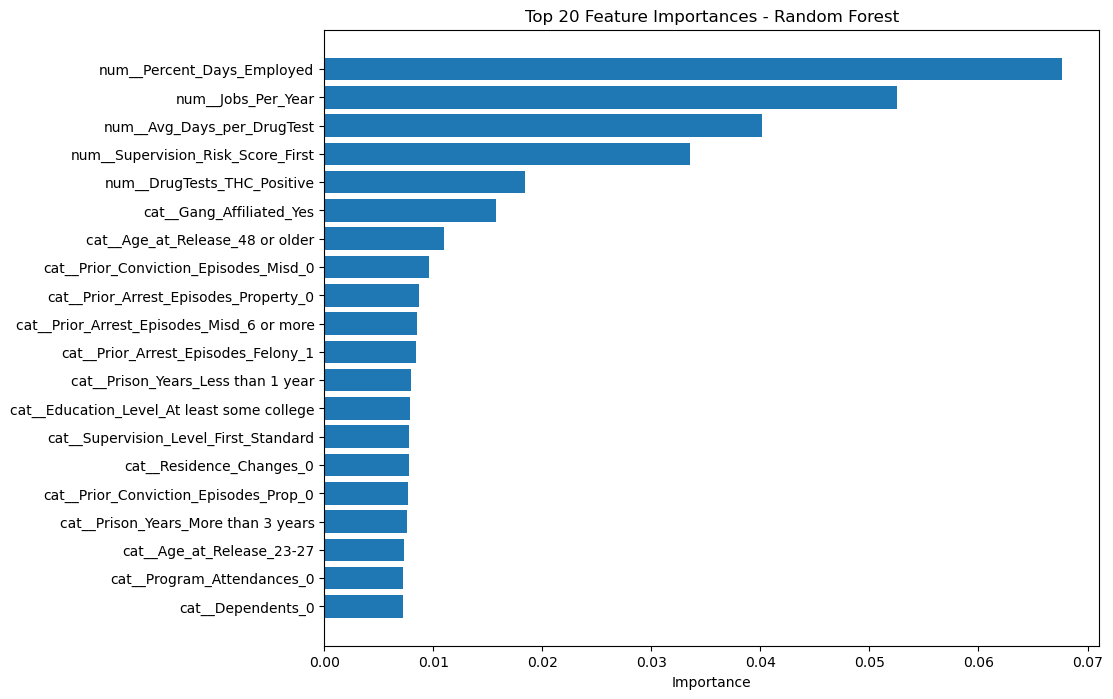

In [150]:
# Plot feature importance
import matplotlib.pyplot as plt

top20 = feature_importance.head(20)

plt.figure(figsize=(10,8))
plt.barh(top20['Feature'], top20['Importance'])
plt.gca().invert_yaxis()
plt.xlabel("Importance")
plt.title("Top 20 Feature Importances - Random Forest")
plt.show()

In [151]:
# Create a dashboard dataset for Power BI 
powerbi_df = model_df.copy()

In [152]:
# Rename columns
powerbi_df.rename(columns={
    'Recidivism_Within_3years':'Recidivism Status',
    'Percent_Days_Employed':'Employment (%)',
    'Jobs_Per_Year':'Jobs per Year',
    'Age_at_Release': 'Age At Release',
    'Residence_PUMA': 'Residence PUMA',
    'Gang_Affiliated': 'Gang Affiliation',
    'Prison_Years': 'Prison Years',
    'Supervision_Level_First': 'Supervision Level First',
    'Education_Level': 'Education Level',
    'Prison_Offense': 'Prison Offense',
    'Employment_Exempt':'Employment Exempt',
    'Program_Attendances':'Programme Attendance',
    'Program_UnexcusedAbsences':'Programme Unexcused Absences',
    'Supervision_Risk_Score_First':'Initial Risk Score',
    'Avg_Days_per_DrugTest':'Average Days Between Drug Tests',
    'DrugTests_THC_Positive':'THC Positive Rate',
    'DrugTests_Cocaine_Positive':'Cocaine Positive Rate',
    'DrugTests_Meth_Positive':'Meth Positive Rate',
    'DrugTests_Other_Positive':'Other Drugs Positive Rate',
    'Prior_Arrest_Episodes_Felony': 'Prior Felony Arrest ',
    'Prior_Arrest_Episodes_Misd': 'Prior Misdemeanour Arrest',
    'Prior_Arrest_Episodes_Violent': 'Prior Violent Arrest',
    'Prior_Arrest_Episodes_Property':'Prior Property Arrest',
    'Prior_Arrest_Episodes_Drug': 'Prior Drug Arrest',
    'Prior_Arrest_Episodes_DVCharges':'Prior DV Charges Arrest',
    'Prior_Arrest_Episodes_GunCharges': 'Prior Gun Charges Arrest',
    'Prior_Revocations_Parole':'Prior Parole Revocation',
    'Prior_Revocations_Probation':'Prior Probation Revocation',
    'Prior_Conviction_Episodes_Felony':'Prior Felony Convictions',
    'Prior_Conviction_Episodes_Misd':'Prior Misdemeanour Convictions',
    'Prior_Conviction_Episodes_Viol':'Prior Violent Convictions',
    'Prior_Conviction_Episodes_Prop':'Prior Property Convictions',
    'Prior_Conviction_Episodes_Drug':'Prior Drug Convictions',
    'Condition_MH_SA': 'Condition MH_SA',
    'Condition_Cog_Ed': 'Condition Cog_Ed',
    'Condition_Other': 'Other Conditions',
    'Violations_ElectronicMonitoring': 'Electronic Monitoring Violations',
    'Violations_Instruction': 'Instruction Violations',
    'Violations_FailToReport': 'Fail-To-Report Violations',
    'Violations_MoveWithoutPermission': 'Move-Without-Permission Violations',
    'Delinquency_Reports': 'Delinquency Reports',
    'Residence_Changes': 'Residence Changes'
}, inplace=True)

In [153]:
powerbi_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25835 entries, 0 to 25834
Data columns (total 46 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Gender                              25835 non-null  object 
 1   Race                                25835 non-null  object 
 2   Age At Release                      25835 non-null  object 
 3   Residence PUMA                      25835 non-null  int64  
 4   Gang Affiliation                    22668 non-null  object 
 5   Initial Risk Score                  25360 non-null  float64
 6   Supervision Level First             24115 non-null  object 
 7   Education Level                     25835 non-null  object 
 8   Dependents                          25835 non-null  object 
 9   Prison Offense                      22558 non-null  object 
 10  Prison Years                        25835 non-null  object 
 11  Prior Felony Arrest                 25835

In [154]:
# Save to folder for powerbi dashboard
powerbi_df.to_excel(r'C:\Users\USER\OneDrive\Desktop\My Briefcase\Full stack analyst\World Prisons\Recidivism\resources\datasets\Recidivism_PowerBI.xlsx', index=False)

In [155]:
top_10_features = feature_importance.head(10)
top_10_features

,Feature,Importance
6,num__Percent_Days_Employed,0.067688
7,num__Jobs_Per_Year,0.052548
1,num__Avg_Days_per_DrugTest,0.040153
0,num__Supervision_Risk_Score_First,0.033562
2,num__DrugTests_THC_Positive,0.018385
20,cat__Gang_Affiliated_Yes,0.015738
18,cat__Age_at_Release_48 or older,0.011016
85,cat__Prior_Conviction_Episodes_Misd_0,0.009640
65,cat__Prior_Arrest_Episodes_Property_0,0.008659
60,cat__Prior_Arrest_Episodes_Misd_6 or more,0.008482


In [156]:
top_10_features.to_excel(r'C:\Users\USER\OneDrive\Desktop\My Briefcase\Full stack analyst\World Prisons\Recidivism\resources\datasets\top_ten_features.xlsx', index=False)

In [157]:
print(df.shape)
print(model_df.shape)
print(model_df['Recidivism_Within_3years'].value_counts())
print(model_df['Recidivism_Within_3years'].value_counts(normalize=True) * 100)

(25835, 62)
(25835, 46)
Recidivism_Within_3years
Yes    14904
No     10931
Name: count, dtype: int64
Recidivism_Within_3years
Yes    57.689181
No     42.310819
Name: proportion, dtype: float64


In [158]:
print("List of model_df columns: \n", model_df.columns.tolist())
print()
print("Data types of model_df: \n", model_df.dtypes)

List of model_df columns: 
 ['Gender', 'Race', 'Age_at_Release', 'Residence_PUMA', 'Gang_Affiliated', 'Supervision_Risk_Score_First', 'Supervision_Level_First', 'Education_Level', 'Dependents', 'Prison_Offense', 'Prison_Years', 'Prior_Arrest_Episodes_Felony', 'Prior_Arrest_Episodes_Misd', 'Prior_Arrest_Episodes_Violent', 'Prior_Arrest_Episodes_Property', 'Prior_Arrest_Episodes_Drug', 'Prior_Arrest_Episodes_DVCharges', 'Prior_Arrest_Episodes_GunCharges', 'Prior_Conviction_Episodes_Felony', 'Prior_Conviction_Episodes_Misd', 'Prior_Conviction_Episodes_Viol', 'Prior_Conviction_Episodes_Prop', 'Prior_Conviction_Episodes_Drug', 'Prior_Revocations_Parole', 'Prior_Revocations_Probation', 'Condition_MH_SA', 'Condition_Cog_Ed', 'Condition_Other', 'Violations_ElectronicMonitoring', 'Violations_Instruction', 'Violations_FailToReport', 'Violations_MoveWithoutPermission', 'Delinquency_Reports', 'Program_Attendances', 'Program_UnexcusedAbsences', 'Residence_Changes', 'Avg_Days_per_DrugTest', 'DrugTes

In [159]:
model_df = model_df.drop(columns=['Recidivism_Within_3years_Status'])

In [160]:
model_df.shape

(25835, 45)

In [161]:
model_df.to_csv(
    r'C:\Users\USER\OneDrive\Desktop\My Briefcase\Full stack analyst\World Prisons\Recidivism\resources\datasets\Recidivism_Model_Dataset_Final.csv',
    index=False
)

In [162]:
print("df shape:", df.shape)
print("model_df shape:", model_df.shape)

print("\nTarget distribution:")
print(df['Recidivism_Within_3years'].value_counts())

print("\nTarget proportions:")
print(
    df['Recidivism_Within_3years']
      .value_counts(normalize=True)
      .mul(100)
      .round(2)
)

print("\nDuplicate rows in df:", df.duplicated().sum())
print("Duplicate rows in model_df:", model_df.duplicated().sum())

print("\nTarget missing values:")
print(df['Recidivism_Within_3years'].isna().sum())

print("\nmodel_df target:")
print(model_df['Recidivism_Within_3years'].value_counts())

print("\nmodel_df columns:", len(model_df.columns))


df shape: (25835, 62)
model_df shape: (25835, 45)

Target distribution:
Recidivism_Within_3years
Yes    14904
No     10931
Name: count, dtype: int64

Target proportions:
Recidivism_Within_3years
Yes    57.69
No     42.31
Name: proportion, dtype: float64

Duplicate rows in df: 0
Duplicate rows in model_df: 0

Target missing values:
0

model_df target:
Recidivism_Within_3years
Yes    14904
No     10931
Name: count, dtype: int64

model_df columns: 45


In [163]:
print("Original df columns:", len(df.columns))
print("Final model_df columns:", len(model_df.columns))

removed_columns = [col for col in df.columns if col not in model_df.columns]

print("\nColumns removed from df:")
for col in removed_columns:
    print("-", col)

print("\nColumns retained in model_df:")
print(model_df.columns.tolist())
print()
created_groups = [
    'Employment_Group',
    'Jobs_Group',
    'DrugTestInterval_Group',
    'THC_Group',
    'Cocaine_Group',
    'Meth_Group',
    'OtherDrugs_Group'
]

print("\nEDA-created groups still in model_df:")
for col in created_groups:
    print(col, "->", col in model_df.columns)
print()
mystery_vars = ['_v1', '_v2', '_v3', '_v4']

print("\nMystery variables:")
for col in mystery_vars:
    print(col, "in df:", col in df.columns,
          "| in model_df:", col in model_df.columns)


Original df columns: 62
Final model_df columns: 45

Columns removed from df:
- ID
- _v1
- _v2
- _v3
- _v4
- Recidivism_Arrest_Year1
- Recidivism_Arrest_Year2
- Recidivism_Arrest_Year3
- Training_Sample
- Employment_Group
- Jobs_Group
- DrugTestInterval_Group
- THC_Group
- Cocaine_Group
- Meth_Group
- OtherDrugs_Group
- Recidivism_Within_3years_Status

Columns retained in model_df:
['Gender', 'Race', 'Age_at_Release', 'Residence_PUMA', 'Gang_Affiliated', 'Supervision_Risk_Score_First', 'Supervision_Level_First', 'Education_Level', 'Dependents', 'Prison_Offense', 'Prison_Years', 'Prior_Arrest_Episodes_Felony', 'Prior_Arrest_Episodes_Misd', 'Prior_Arrest_Episodes_Violent', 'Prior_Arrest_Episodes_Property', 'Prior_Arrest_Episodes_Drug', 'Prior_Arrest_Episodes_DVCharges', 'Prior_Arrest_Episodes_GunCharges', 'Prior_Conviction_Episodes_Felony', 'Prior_Conviction_Episodes_Misd', 'Prior_Conviction_Episodes_Viol', 'Prior_Conviction_Episodes_Prop', 'Prior_Conviction_Episodes_Drug', 'Prior_Revocat

In [164]:
print("Missing values in model_df:")
missing_model = model_df.isnull().sum().sort_values(ascending=False)

print(missing_model[missing_model > 0])
print()
print("\nTotal missing cells in model_df:")
print(model_df.isnull().sum().sum())
print()
print("\nData types in model_df:")
print(model_df.dtypes.value_counts())
print()
numeric_cols = model_df.select_dtypes(include='number').columns

print("\nNumerical summary:")
print(model_df[numeric_cols].describe().T)


Missing values in model_df:
Avg_Days_per_DrugTest           6103
DrugTests_THC_Positive          5172
DrugTests_Meth_Positive         5172
DrugTests_Cocaine_Positive      5172
DrugTests_Other_Positive        5172
Prison_Offense                  3277
Gang_Affiliated                 3167
Supervision_Level_First         1720
Jobs_Per_Year                    808
Supervision_Risk_Score_First     475
Percent_Days_Employed            462
dtype: int64


Total missing cells in model_df:
36700


Data types in model_df:
object     36
float64     8
int64       1
Name: count, dtype: int64


Numerical summary:
                                count       mean         std  min        25%  \
Residence_PUMA                25835.0  12.361796    7.133742  1.0   6.000000   
Supervision_Risk_Score_First  25360.0   6.082216    2.381442  1.0   4.000000   
Avg_Days_per_DrugTest         19732.0  93.890044  117.169847  0.5  28.837366   
DrugTests_THC_Positive        20663.0   0.063350    0.138453  0.0   0.000000

In [165]:
#print(log_model)
print(log_model.named_steps['preprocessor'])

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median'))]),
                                 ['Supervision_Risk_Score_First',
                                  'Avg_Days_per_DrugTest',
                                  'DrugTests_THC_Positive',
                                  'DrugTests_Cocaine_Positive',
                                  'DrugTests_Meth_Positive',
                                  'DrugTests_Other_Positive',
                                  'Percent_Days_Employed', 'Jobs_Per_Year']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImp...
                                  'Prior_Conviction_Episodes_Misd',
                                  'Prior_Conviction_Episodes_Viol',
                                  'Prior_Conviction_Episodes_P

In [166]:
print(log_model.named_steps['preprocessor'].transformers_[1][1])

Pipeline(steps=[('imputer', SimpleImputer(strategy='most_frequent')),
                ('encoder', OneHotEncoder(handle_unknown='ignore'))])


In [167]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

print("\ny_train distribution:")
print(y_train.value_counts())

print("\ny_test distribution:")
print(y_test.value_counts())

print("\ny_train proportions:")
print(y_train.value_counts(normalize=True).round(4))

print("\ny_test proportions:")
print(y_test.value_counts(normalize=True).round(4))
print()
print("X_train columns:", X_train.shape[1])
print("X_test columns:", X_test.shape[1])


X_train shape: (20668, 45)
X_test shape: (5167, 45)

y_train distribution:
Recidivism_Within_3years
Yes    11923
No      8745
Name: count, dtype: int64

y_test distribution:
Recidivism_Within_3years
Yes    2981
No     2186
Name: count, dtype: int64

y_train proportions:
Recidivism_Within_3years
Yes    0.5769
No     0.4231
Name: proportion, dtype: float64

y_test proportions:
Recidivism_Within_3years
Yes    0.5769
No     0.4231
Name: proportion, dtype: float64

X_train columns: 45
X_test columns: 45


In [168]:
print("Logistic Regression:", type(log_model))
print("Decision Tree:", type(tree_model))
print("Random Forest:", type(rf_model))
print()
print("\nLogistic Regression steps:")
print(log_model.named_steps.keys())

print("\nDecision Tree steps:")
print(tree_model.named_steps.keys())

print("\nRandom Forest steps:")
print(rf_model.named_steps.keys())

Logistic Regression: <class 'sklearn.pipeline.Pipeline'>
Decision Tree: <class 'sklearn.pipeline.Pipeline'>
Random Forest: <class 'sklearn.pipeline.Pipeline'>


Logistic Regression steps:
dict_keys(['preprocessor', 'classifier'])

Decision Tree steps:
dict_keys(['preprocessor', 'classifier'])

Random Forest steps:
dict_keys(['preprocessor', 'classifier'])


In [169]:
print("Logistic preprocessor:")
print(log_model.named_steps['preprocessor'])

print("\nDecision Tree preprocessor:")
print(tree_model.named_steps['preprocessor'])

print("\nRandom Forest preprocessor:")
print(rf_model.named_steps['preprocessor'])

Logistic preprocessor:
ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median'))]),
                                 ['Supervision_Risk_Score_First',
                                  'Avg_Days_per_DrugTest',
                                  'DrugTests_THC_Positive',
                                  'DrugTests_Cocaine_Positive',
                                  'DrugTests_Meth_Positive',
                                  'DrugTests_Other_Positive',
                                  'Percent_Days_Employed', 'Jobs_Per_Year']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImp...
                                  'Prior_Conviction_Episodes_Misd',
                                  'Prior_Conviction_Episodes_Viol',
                                  'Prio

In [170]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

models = {
    "Logistic Regression": log_model,
    "Decision Tree": tree_model,
    "Random Forest": rf_model
}

for name, model in models.items():
    
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    
    print("\n" + "="*60)
    print(name)
    print("="*60)
    
    print("Accuracy :", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred, pos_label="Yes"))
    print("Recall   :", recall_score(y_test, y_pred, pos_label="Yes"))
    print("F1 Score :", f1_score(y_test, y_pred, pos_label="Yes"))
    print("ROC AUC  :", roc_auc_score(
        (y_test == "Yes").astype(int),
        y_prob
    ))
    
    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))



Logistic Regression
Accuracy : 0.7124056512483066
Precision: 0.7279658432448918
Recall   : 0.8007380073800738
F1 Score : 0.7626198083067093
ROC AUC  : 0.7755145196798386

Confusion Matrix:
[[1294  892]
 [ 594 2387]]

Classification Report:
              precision    recall  f1-score   support

          No       0.69      0.59      0.64      2186
         Yes       0.73      0.80      0.76      2981

    accuracy                           0.71      5167
   macro avg       0.71      0.70      0.70      5167
weighted avg       0.71      0.71      0.71      5167


Decision Tree
Accuracy : 0.6425391910199342
Precision: 0.6900134048257373
Recall   : 0.6907078161690707
F1 Score : 0.690360435875943
ROC AUC  : 0.6337802575813332

Confusion Matrix:
[[1261  925]
 [ 922 2059]]

Classification Report:
              precision    recall  f1-score   support

          No       0.58      0.58      0.58      2186
         Yes       0.69      0.69      0.69      2981

    accuracy                      

In [171]:
# Get the fitted preprocessor
preprocessor = rf_model.named_steps['preprocessor']

# Get the fitted Random Forest
rf = rf_model.named_steps['classifier']

# Get feature names after preprocessing
feature_names = preprocessor.get_feature_names_out()

# Get feature importances
importances = rf.feature_importances_

# Create a feature-importance table
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False)

# Display top 20
feature_importance_df.head(20)


,Feature,Importance
6,num__Percent_Days_Employed,0.067688
7,num__Jobs_Per_Year,0.052548
1,num__Avg_Days_per_DrugTest,0.040153
0,num__Supervision_Risk_Score_First,0.033562
2,num__DrugTests_THC_Positive,0.018385
20,cat__Gang_Affiliated_Yes,0.015738
18,cat__Age_at_Release_48 or older,0.011016
85,cat__Prior_Conviction_Episodes_Misd_0,0.009640
65,cat__Prior_Arrest_Episodes_Property_0,0.008659
60,cat__Prior_Arrest_Episodes_Misd_6 or more,0.008482
